In [1]:
import numpy as np
import matplotlib.pyplot as plt
from regions import Regions
import regions
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord 
from astropy import units as u
from astropy.modeling import models, fitting

from dust_extinction.averages import CT06_MWGC 

from smart_plotters.jwst_plots import JWSTCatalog, make_cat_use, make_brick_cat
from smart_plotters.cutout_plot import get_cutout_405, get_cutout_jwst_ice
import smart_plotters.co_ice as co_map
from icemodels.colorcolordiagrams import plot_ccd_icemodels
from smart_plotters import cmd_plot 
from sklearn.mixture import GaussianMixture
from mpl_plot_templates import adaptive_param_plot
from scipy.optimize import curve_fit 
from scipy.signal import find_peaks, argrelextrema

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
/blue/adamginsburg/adamginsburg/jwst/brick-jwst-2221/brick2221/analysis/plot_tools.py:804: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'{filtername} $\mu$={np.median(sep).to(u.marcsec).value:0.1f} $\sigma$={np.std(sep).to(u.marcsec).value:0.1f}', fontsize=10)
/blue/adamginsburg/adamginsburg/jwst/brick-jwst-2221/brick2221/analysis/plot_tools.py:804: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'{filtername} $\mu$={np.median(sep).to(u.marcsec).value:0.1f} $\sigma$={np.std(sep).to(u.marcsec).value:0.1f}', fontsize=10)
        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]


In [2]:
radius = 100*u.parsec
circumference = 2*np.pi*radius
velocity = 200*u.km/u.s
time = circumference/velocity
print(time.to(u.Myr))

3.0718248603696097 Myr


In [3]:
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/2/sigma**2)

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

In [4]:
def get_intersection_locations(y1,y2,test=False,x=None): 
    """
    return indices of the intersection point/s.
    """
    idxs=np.argwhere(np.diff(np.sign(y1 - y2))).flatten()
    if test:
        x=range(len(y1)) if x is None else x
        plt.figure(figsize=[2.5,2.5])
        ax=plt.subplot()
        ax.plot(x,y1,color='r',label='line1',alpha=0.5)
        ax.plot(x,y2,color='b',label='line2',alpha=0.5)
        _=[ax.axvline(x[i],color='k') for i in idxs]
        _=[ax.text(x[i],ax.get_ylim()[1],f"{x[i]:1.1f}",ha='center',va='bottom') for i in idxs]
        ax.legend(bbox_to_anchor=[1,1])
        ax.set(xlabel='x',ylabel='density')
    return idxs

In [5]:
def get_rc_sel_mask(cat):
    x = np.linspace(0, 2.5, 10)
    
    x0 = 0.52
    mask_x0_left = cat.color('f182m', 'f212n') > x0

    y0 = 14.8
    mask_above_y0 = cat.band('f182m') > y0
    mask_rc = mask_above_y0 & mask_x0_left

    pt1 = (0.5, 14.3)
    pt2 = (2.0, 20.)
    y1 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_below_y1 = cat.band('f182m') > ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_below_y1 & mask_rc

    pt1 = (0.5, 15.5)
    pt2 = (2.0, 20.9)
    y2 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_above_y2 = cat.band('f182m') < ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_rc & mask_above_y2

    return mask_rc

In [6]:
starting_params = {
    # bin number, mu1, sigma1, A1, mu2, sigma2, A2
    'Filament' : (30, 40, 10, 80, 15, 1, 60),
    'Cloud C1' : (30, 19, 1, 40, 27, 10, 60),
    'Cloud C2' : (30, 19, 1, 40, 27, 10, 60),
    'Cloud D' : (30, 19, 3, 60, 30, 15, 40),
    'Cloud B' : (40, 30, 10, 20, 19, 1, 30),
    'Filament Right' : (30, 19, 1, 40, 30, 5, 40),
    'Left Cloud D' : (40, 18, 0.5, 60, 23, 5, 100),
    'Cloud C North' : (50, 19, 2, 20, 27, 5, 35),
    'Cloud C South' : (30, 19, 1, 40, 27, 10, 60),

    'Brick North' : (40, 20, 2, 20, 27, 10, 35),
    'Brick South' : (40, 20, 2, 80, 40, 10, 20),
    'Brick Head' : (40, 19, 1, 30, 35, 10, 20),
    'Brick South Fluff' : (40, 20, 1, 40, 27, 10, 60),
    'Brick North Fluff' : (40, 20, 0.5, 20, 30, 5, 20),
    'Brick SFR' : (40, 22, 1, 15, 40, 10, 5),
    'Brick SFR Wide' : (50, 25, 10, 20, 40, 10, 10),
    'Brick Punch' : (40, 19, 1, 40, 27, 10, 60),

    'Brick S Fore' : (30, 30, 10, 40, 30, 10, 40),

    'Brick N Clear' : (40, 18, 2, 30, 26, 2, 40),
    'Brick Top C' : (35, 18, 2, 8, 27, 2, 10)
}

# Cloud C

In [7]:
cat_use = make_cat_use()
cat_use.catalog['Av'] = cat_use.get_Av('f182m', 'f212n')
cat_use.catalog['N(CO)'] = co_map.get_co_ice_column(cat_use, cat_use.catalog['Av'], ext=CT06_MWGC(), ref_band='f405n')

In [8]:
cat_rc = JWSTCatalog(cat_use.catalog[get_rc_sel_mask(cat_use)])

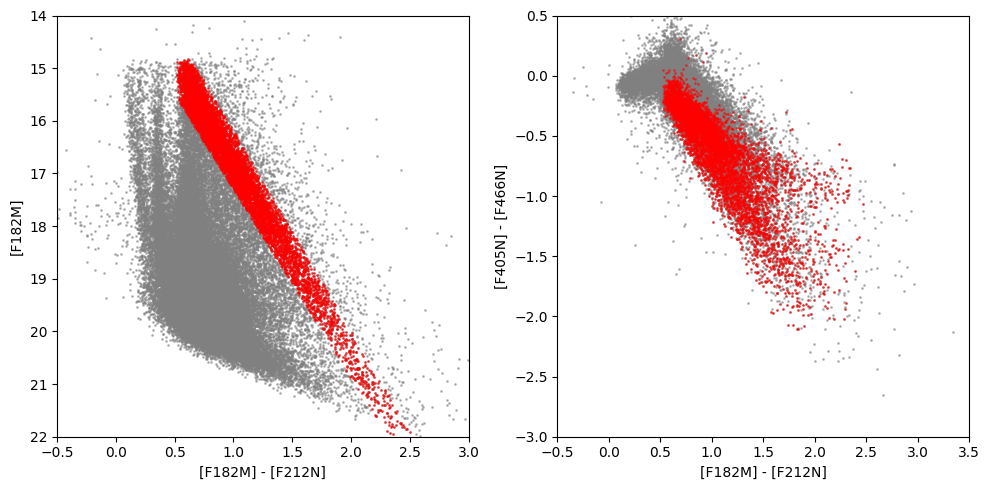

In [9]:
fig = plt.figure(figsize=[10,5])
ax1 = plt.subplot(121)
cat_use.plot_CMD('f182m', 'f212n', 'f182m', color='grey', alpha=0.5, s=1, ax=ax1)
cat_rc.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=0.5, s=1, ax=ax1)
ax1.set_xlim(-0.5, 3)
ax1.set_ylim(22, 14)

ax2 = plt.subplot(122)
cat_use.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='grey', alpha=0.5, s=1, ax=ax2)
cat_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='red', alpha=0.5, s=1, ax=ax2)
ax2.set_xlim(-0.5, 3.5)
ax2.set_ylim(-3, 0.5)

plt.tight_layout()

In [10]:
fn = '/orange/adamginsburg/jwst/cloudc/images/jw02221-o002_t001_nircam_clear-f405n-merged_i2d.fits'
hdu = fits.open(fn)
ww = WCS(hdu['SCI'].header)
nanfield = np.nan * hdu['SCI'].data

In [11]:
reg_f = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/filament_short.region')
reg_b = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudb.region')
reg_c1 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudc1_ice.reg')
reg_c2 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudc2_ice.reg')
reg_d = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudd_ice.reg')
reg_fil_r = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/filament_right.region')
reg_left_cd = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/left_cloudd.region')
reg_c_n = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudc_north.region')
reg_c_s = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudc_south.region')

In [12]:
cat_f = JWSTCatalog(cat_use.table_region_mask(reg_f, ww))
cat_c1 = JWSTCatalog(cat_use.table_region_mask(reg_c1, ww))
cat_c2 = JWSTCatalog(cat_use.table_region_mask(reg_c2, ww))
cat_c = JWSTCatalog(cat_use.table_region_mask([reg_c1[0], reg_c2[0]], ww))
cat_d = JWSTCatalog(cat_use.table_region_mask(reg_d, ww))
cat_b = JWSTCatalog(cat_use.table_region_mask(reg_b, ww))
cat_fil_r = JWSTCatalog(cat_use.table_region_mask(reg_fil_r, ww))
cat_left_cd = JWSTCatalog(cat_use.table_region_mask(reg_left_cd, ww))
cat_c_n = JWSTCatalog(cat_use.table_region_mask(reg_c_n, ww))
cat_c_s = JWSTCatalog(cat_use.table_region_mask(reg_c_s, ww))

In [13]:
cat_f_rc = JWSTCatalog(cat_rc.table_region_mask(reg_f, ww))
cat_c1_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c1, ww))
cat_c2_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c2, ww))
cat_c_rc = JWSTCatalog(cat_rc.table_region_mask([reg_c1[0], reg_c2[0]], ww))
cat_d_rc = JWSTCatalog(cat_rc.table_region_mask(reg_d, ww))
cat_b_rc = JWSTCatalog(cat_rc.table_region_mask(reg_b, ww))
cat_fil_r_rc = JWSTCatalog(cat_rc.table_region_mask(reg_fil_r, ww))
cat_left_cd_rc = JWSTCatalog(cat_rc.table_region_mask(reg_left_cd, ww))
cat_c_n_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c_n, ww))
cat_c_s_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c_s, ww))

catalogs_cloudc = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc, cat_b_rc, cat_fil_r_rc, cat_left_cd_rc, cat_c_n_rc, cat_c_s_rc]
labels_cloudc = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South']
colors_cloudc = ['k', 'r', 'g', 'b', 'orange', 'magenta', 'grey', 'cyan', 'purple']


/scratch/local/31455051/ipykernel_3450433/1385153100.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  params, cov = curve_fit(bimodal, x, y, expected)


Filament: one of the gaussians has a negative amplitude, skipping intersection and high Av calculation


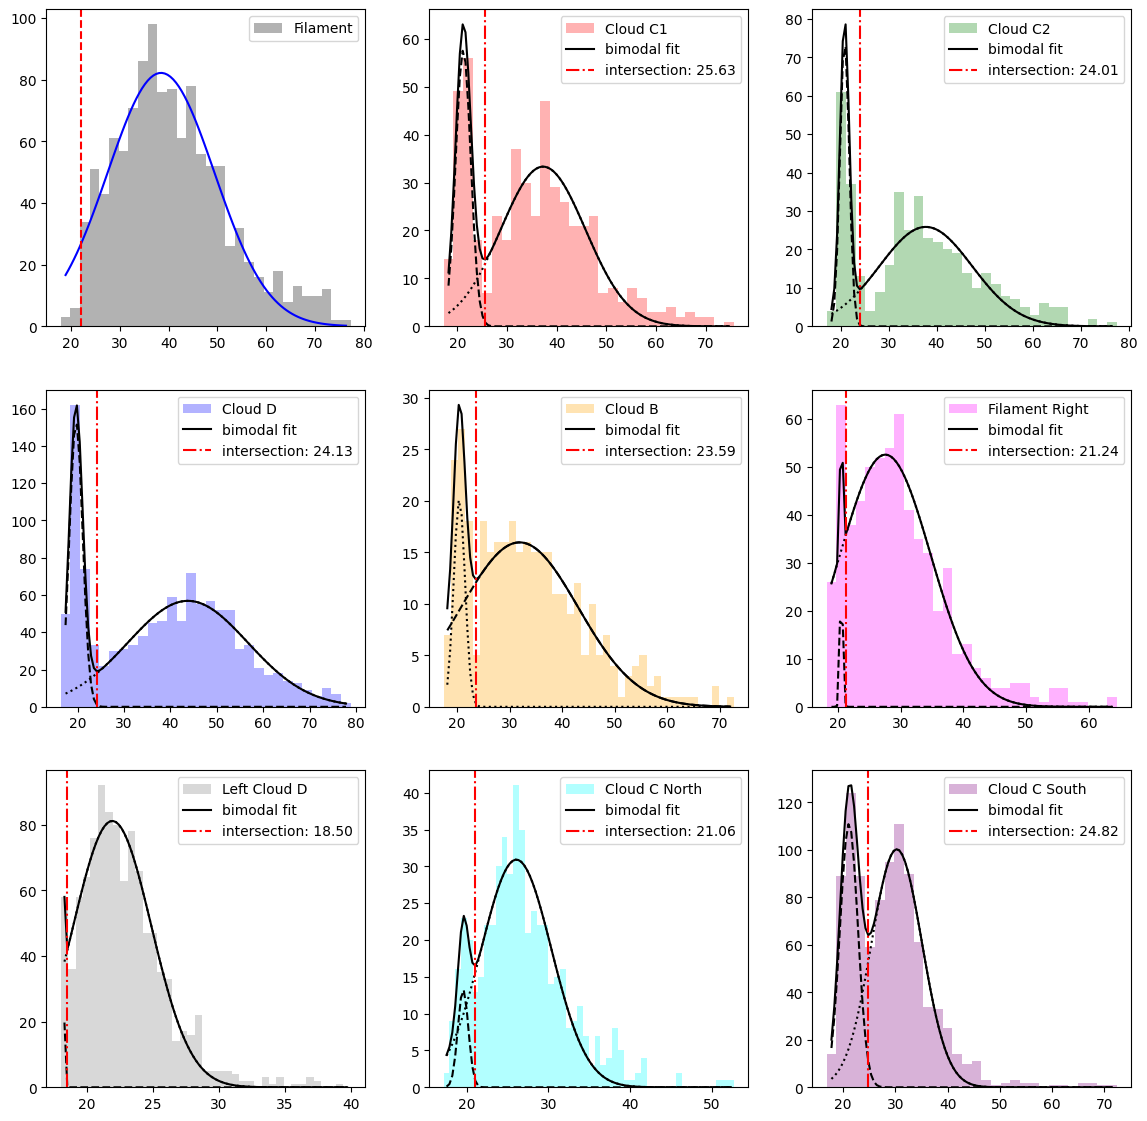

In [14]:
fig, axes = plt.subplots(3, 3, figsize=[14,14])#, sharex=True)
intersections_cloudc = []
highAv_cloudc = []

for i in range(9):
    ax = axes.flatten()[i]
    cat = catalogs_cloudc[i]
    data = cat.catalog['Av'].flatten()
    label = labels_cloudc[i]
    bin_num = starting_params[label][0]
    if label in ['Left Cloud D']:
        bins = np.linspace(18, 40, bin_num)
        y,x,_=ax.hist(data, bins=bins, alpha=.3, label=label, color=colors_cloudc[i])
    else:
        y,x,_=ax.hist(data, bin_num, alpha=.3, label=label, color=colors_cloudc[i])
    x=(x[1:]+x[:-1])/2

    mu1_guess = starting_params[label][1]
    sigma1_guess = starting_params[label][2]
    A1_guess = starting_params[label][3]

    mu2_guess = starting_params[label][4]
    sigma2_guess = starting_params[label][5]
    A2_guess = starting_params[label][6]

    expected = (mu1_guess, sigma1_guess, A1_guess, mu2_guess, sigma2_guess, A2_guess)

    try: 
        params, cov = curve_fit(bimodal, x, y, expected)
    except:
        print(f"{labels_cloudc[i]}: failed to fit bimodal")
        intersections_cloudc.append(np.nan)
        highAv_cloudc.append(np.nan)
        ax.legend(loc='upper right')
        continue
    if params[2] < 0 or params[5] < 0:
        print(f"{labels_cloudc[i]}: one of the gaussians has a negative amplitude, skipping intersection and high Av calculation")
        intersections_cloudc.append(np.nan)
        highAv_cloudc.append(np.nan)
        ax.legend(loc='upper right')
        continue

    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = bimodal(x_fit, *params)
    ax.plot(x_fit, y_fit, color='k', label='bimodal fit')
    ax.plot(x_fit, gauss(x_fit, *params[:3]), color='k', linestyle='--')
    ax.plot(x_fit, gauss(x_fit, *params[3:6]), color='k', linestyle=':')

    # find local minimum between the two peaks 
    #peaks, _ = find_peaks(y_fit)
    #ax.scatter(x_fit[peaks], y_fit[peaks], color='orange', label='peaks')
    minima, _ = find_peaks(-y_fit)
    #ax.scatter(x_fit[minima], y_fit[minima], color='green', label='minima')
    intersection = x_fit[minima]
    if len(intersection) == 0:
        print(f"{labels_cloudc[i]}: no intersection found")
        intersections_cloudc.append(np.nan)
        highAv_cloudc.append(np.nan)
        ax.legend(loc='upper right')
        continue
    elif len(intersection) > 1:
        print(f"{labels_cloudc[i]}: multiple intersections found at {intersection}, using the one between the two peaks")
        if params[0] < params[3]: # if the first gaussian has a smaller mean than the second gaussian
            intersections_cloudc.append(intersection[intersection > params[0]][intersection[intersection > params[0]] < params[3]][0])
        elif params[0] > params[3]:
            intersections_cloudc.append(intersection[intersection > params[3]][intersection[intersection > params[3]] < params[0]][0])
    elif len(intersection) == 1:
        intersections_cloudc.append(intersection[0])
    ax.axvline(intersections_cloudc[-1], color='r', linestyle='-.', label=f'intersection: {intersections_cloudc[-1]:.2f}')
    highAv_cloudc.append(params[3]+2*params[4]) # mean + 2 sigma of the second gaussian, which should correspond to the high Av population

    ax.legend(loc='upper right')

for i in range(9):
    intersection = intersections_cloudc[i]
    ax = axes.flatten()[i]
    if intersection == -1:
        # fit with a bimodial and use the location of the minimum between the two peaks as the intersection, and set high Av to be the mean + 2 sigma of the second gaussian
        continue
    elif ~np.isnan(intersection):
        continue
    else:
        # fit with a single gaussian and use the mean + 2 sigma as the high Av
        label = labels_cloudc[i]
        mu_guess = starting_params[label][1]
        sigma_guess = starting_params[label][2]
        A_guess = starting_params[label][3]
        expected = (mu_guess, sigma_guess, A_guess)
        cat = catalogs_cloudc[i]
        data = cat.catalog['Av'].flatten()
        x = np.linspace(data.min(), data.max(), 100)
        bin_num = starting_params[label][0]
        if label in ['Left Cloud D']:
            bins = np.linspace(18, 40, bin_num)
            y,x_bins,_=ax.hist(data, bins=bins, alpha=.3, label=label, color=colors_cloudc[i])
        else:
            y, x_bins = np.histogram(data, bins=starting_params[label][0])
        x = (x_bins[1:] + x_bins[:-1]) / 2
        try:
            params, cov = curve_fit(gauss, x, y, expected)
        except:
            print(f"{labels_cloudc[i]}: failed to fit single gaussian")
            intersections_cloudc[i] = np.nan
            highAv_cloudc[i] = np.nan
            continue
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = gauss(x_fit, *params)
        ax.plot(x_fit, y_fit, color='b', label='gaussian fit')
        ax.axvline(params[0]-1.5*params[1], color='r', linestyle='--')#, label=f'gaussian mean - sigma: {params[0]-1.5*params[1]:.2f}')
        intersections_cloudc[i] = params[0]-1.5*params[1]

/scratch/local/31455051/ipykernel_3450433/1092640326.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  params, cov = curve_fit(bimodal, x, y, expected)


Filament: one of the gaussians has a negative amplitude, skipping intersection and high Av calculation
Cloud C2: multiple intersections found at [18.11207242 22.83258199], using the one between the two peaks
Cloud B: intersection at 21.410377343693913 is too close to the mean of either gaussian, trying to find minimum of bimodal fit
Cloud B: minimum found at [23.58596627], using that as the intersection
Filament Right: no intersection found, trying to find minimum of bimodal fit
Filament Right: minimum found at [21.2418461], using that as the intersection
Left Cloud D: no intersection found, trying to find minimum of bimodal fit
Left Cloud D: minimum found at [18.4985755], using that as the intersection
Cloud C North: intersection at 18.594563921996798 is too close to the mean of either gaussian, trying to find minimum of bimodal fit
Cloud C North: minimum found at [21.05598551], using that as the intersection
Filament: no intersection found from bimodal fit, trying single gaussian fit

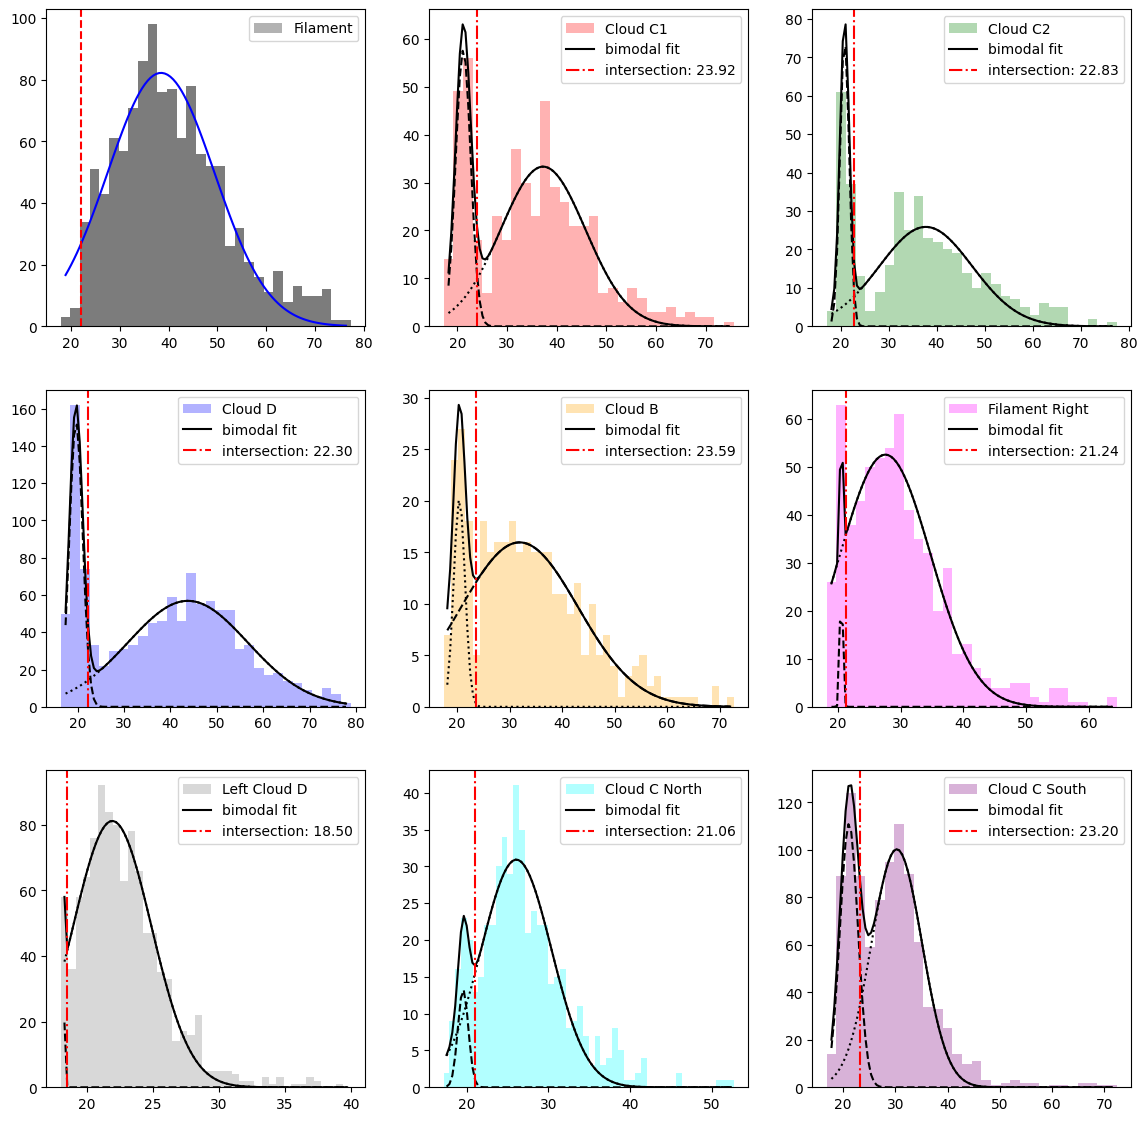

In [15]:
fig, axes = plt.subplots(3, 3, figsize=[14,14])#, sharex=True)
intersections_cloudc = []
highAv_cloudc = []

for i in range(9):
    ax = axes.flatten()[i]
    cat = catalogs_cloudc[i]
    data = cat.catalog['Av'].flatten()
    label = labels_cloudc[i]
    bin_num = starting_params[label][0]
    if label in ['Left Cloud D']:
        bins = np.linspace(18, 40, bin_num)
        y,x,_=ax.hist(data, bins=bins, alpha=.3, label=label, color=colors_cloudc[i])
    else:
        y,x,_=ax.hist(data, bin_num, alpha=.3, label=label, color=colors_cloudc[i])
    x=(x[1:]+x[:-1])/2

    mu1_guess = starting_params[label][1]
    sigma1_guess = starting_params[label][2]
    A1_guess = starting_params[label][3]

    mu2_guess = starting_params[label][4]
    sigma2_guess = starting_params[label][5]
    A2_guess = starting_params[label][6]

    expected = (mu1_guess, sigma1_guess, A1_guess, mu2_guess, sigma2_guess, A2_guess)

    try: 
        params, cov = curve_fit(bimodal, x, y, expected)
    except:
        print(f"{labels_cloudc[i]}: failed to fit bimodal")
        intersections_cloudc.append(np.nan)
        highAv_cloudc.append(np.nan)
        ax.legend(loc='upper right')
        continue
    if params[2] < 0 or params[5] < 0:
        print(f"{labels_cloudc[i]}: one of the gaussians has a negative amplitude, skipping intersection and high Av calculation")
        intersections_cloudc.append(np.nan)
        highAv_cloudc.append(np.nan)
        ax.legend(loc='upper right')
        continue

    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = bimodal(x_fit, *params)
    ax.plot(x_fit, y_fit, color='k', label='bimodal fit')
    ax.plot(x_fit, gauss(x_fit, *params[:3]), color='k', linestyle='--')
    ax.plot(x_fit, gauss(x_fit, *params[3:6]), color='k', linestyle=':')

    intersection = get_intersection_locations(gauss(x_fit, *params[:3]), gauss(x_fit, *params[3:6]), x=x_fit)
    intersection = x_fit[intersection]

    too_close = 1

    # if the intersection is too close to the mean of either gaussian, then it is likely not a real intersection and we should use the minimum between the two peaks as the intersection, and set high Av to be the mean + 2 sigma of the second gaussian
    if len(intersection) == 1:
        if np.logical_or(np.logical_and(intersection < params[0]+too_close, intersection > params[0]-too_close), np.logical_and(intersection < params[3]+too_close, intersection > params[3]-too_close)):
            print(f"{labels_cloudc[i]}: intersection at {intersection} is too close to the mean of either gaussian, trying to find minimum of bimodal fit")
            minima, _ = find_peaks(-y_fit)
            if len(minima) == 0:
                print(f"{labels_cloudc[i]}: no minimum found, skipping intersection and high Av calculation")
                intersections_cloudc.append(np.nan)
                highAv_cloudc.append(np.nan)
                ax.legend(loc='upper right')
                continue
            else:
                print(f"{labels_cloudc[i]}: minimum found at {x_fit[minima]}, using that as the intersection")
                intersections_cloudc.append(x_fit[minima][0])
                highAv_cloudc.append(params[3]+2*params[4]) # mean + 2 sigma of the second gaussian, which should correspond to the high Av population
        else: 
            intersections_cloudc.append(intersection[0])
            highAv_cloudc.append(params[3]+2*params[4]) # mean + 2 sigma of the second gaussian, which should correspond to the high Av population
    elif len(intersection) == 2:
        # if either of the two intersections is too close to the mean
        # then use the minimum between the two peaks as the intersection, and set high Av to be the mean + 2 sigma of the second gaussian
        if np.logical_or(np.logical_and(intersection[0] < params[0]+too_close, intersection[0] > params[0]-too_close), np.logical_and(intersection[0] < params[3]+too_close, intersection[0] > params[3]-too_close)):
            print(f"{labels_cloudc[i]}: intersection at {intersection[0]} is too close to the mean of either gaussian, trying to find minimum of bimodal fit")
            minima, _ = find_peaks(-y_fit)
            if len(minima) == 0:
                print(f"{labels_cloudc[i]}: no minimum found, skipping intersection and high Av calculation")
                intersections_cloudc.append(np.nan)
                highAv_cloudc.append(np.nan)
                ax.legend(loc='upper right')
                continue
            else:
                print(f"{labels_cloudc[i]}: minimum found at {x_fit[minima]}, using that as the intersection")
                intersections_cloudc.append(x_fit[minima][0])
                highAv_cloudc.append(params[3]+2*params[4]) # mean + 2 sigma of the second gaussian, which should correspond to the high Av population
        elif np.logical_or(np.logical_and(intersection[1] < params[0]+too_close, intersection[1] > params[0]-too_close), np.logical_and(intersection[1] < params[3]+too_close, intersection[1] > params[3]-too_close)):
            print(f"{labels_cloudc[i]}: intersection at {intersection[1]} is too close to the mean of either gaussian, trying to find minimum of bimodal fit")
            minima, _ = find_peaks(-y_fit)
            if len(minima) == 0:
                print(f"{labels_cloudc[i]}: no minimum found, skipping intersection and high Av calculation")
                intersections_cloudc.append(np.nan)
                highAv_cloudc.append(np.nan)
                ax.legend(loc='upper right')
                continue
            else:
                print(f"{labels_cloudc[i]}: minimum found at {x_fit[minima]}, using that as the intersection")
                intersections_cloudc.append(x_fit[minima][0])
                highAv_cloudc.append(params[3]+2*params[4]) # mean + 2 sigma of the second gaussian, which should correspond to the high Av population
        else: 
            print(f"{labels_cloudc[i]}: multiple intersections found at {intersection}, using the one between the two peaks")
            if params[0] < params[3]: # if the first gaussian has a smaller mean than the second gaussian
                if np.logical_and(intersection[0] > params[0], intersection[0] < params[3]):
                    intersections_cloudc.append(intersection[0])
                elif np.logical_and(intersection[1] > params[0], intersection[1] < params[3]):
                    intersections_cloudc.append(intersection[1])
            elif params[0] > params[3]:
                if np.logical_and(intersection[0] > params[3], intersection[0] < params[0]):
                    intersections_cloudc.append(intersection[0])
                elif np.logical_and(intersection[1] > params[3], intersection[1] < params[0]):
                    intersections_cloudc.append(intersection[1])
            highAv_cloudc.append(params[3]+2*params[4]) # mean + 2 sigma of the second gaussian, which should correspond to the high Av population
    elif len(intersection) == 0:
        print(f"{labels_cloudc[i]}: no intersection found, trying to find minimum of bimodal fit")
        minima, _ = find_peaks(-y_fit)
        if len(minima) == 0:
            print(f"{labels_cloudc[i]}: no minimum found, skipping intersection and high Av calculation")
            intersections_cloudc.append(np.nan)
            highAv_cloudc.append(np.nan)
            ax.legend(loc='upper right')
            continue
        else:
            print(f"{labels_cloudc[i]}: minimum found at {x_fit[minima]}, using that as the intersection")
            intersections_cloudc.append(x_fit[minima][0])
            highAv_cloudc.append(params[3]+2*params[4]) # mean + 2 sigma of the second gaussian, which should correspond to the high Av population
    
    ax.axvline(intersections_cloudc[-1], color='r', linestyle='-.', label=f'intersection: {intersections_cloudc[-1]:.2f}')


    ax.legend(loc='upper right')

for i in range(9):
    intersection = intersections_cloudc[i]
    ax = axes.flatten()[i]
    if intersection == -1:
        # fit with a bimodial and use the location of the minimum between the two peaks as the intersection, and set high Av to be the mean + 2 sigma of the second gaussian
        continue
    elif ~np.isnan(intersection):
        continue
    else:
        # fit with a single gaussian and use the mean + 2 sigma as the high Av
        print(f"{labels_cloudc[i]}: no intersection found from bimodal fit, trying single gaussian fit")
        label = labels_cloudc[i]
        mu_guess = starting_params[label][1]
        sigma_guess = starting_params[label][2]
        A_guess = starting_params[label][3]
        expected = (mu_guess, sigma_guess, A_guess)
        cat = catalogs_cloudc[i]
        data = cat.catalog['Av'].flatten()
        bin_num = starting_params[label][0]
        if label in ['Left Cloud D']:
            bins = np.linspace(18, 40, bin_num)
            y,x_bins,_= ax.hist(data, bins=bins, alpha=.3, label=label, color=colors_cloudc[i])
        else:
            y,x_bins,_ = ax.hist(data, bins=starting_params[label][0], alpha=.3, label=label, color=colors_cloudc[i])
        x = (x_bins[1:] + x_bins[:-1]) / 2
        try:
            params, cov = curve_fit(gauss, x, y, expected)
        except:
            print(f"{labels_cloudc[i]}: failed to fit single gaussian")
            intersections_cloudc[i] = np.nan
            highAv_cloudc[i] = np.nan
            continue
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = gauss(x_fit, *params)
        ax.plot(x_fit, y_fit, color='b', label='gaussian fit')
        ax.axvline(params[0]-1.5*params[1], color='r', linestyle='--')#, label=f'gaussian mean - sigma: {params[0]-1.5*params[1]:.2f}')
        intersections_cloudc[i] = params[0]-1.5*params[1]

In [16]:
intersection

np.float64(23.196079841827174)

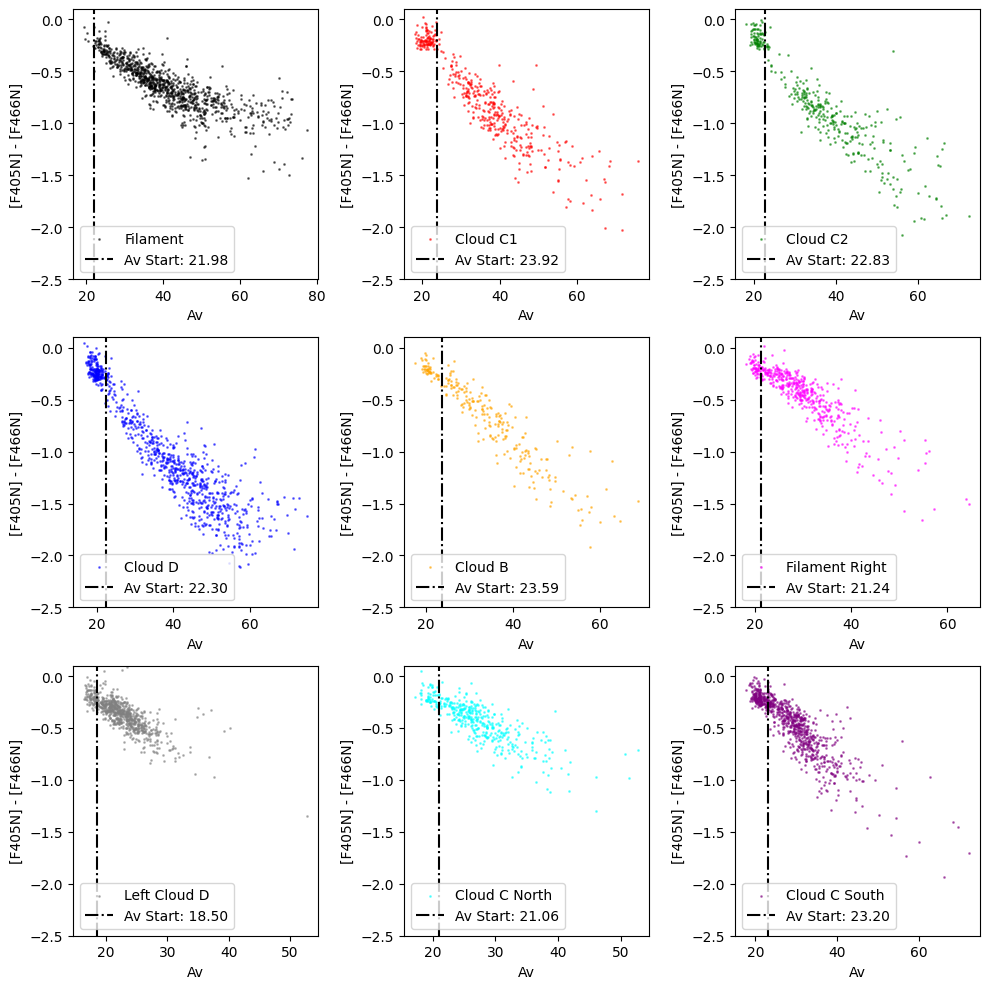

In [17]:
fig, axes = plt.subplots(3, 3, figsize=[10,10])

for i in range(9):
    ax = axes.flatten()[i]
    cat = catalogs_cloudc[i]

    ax.scatter(cat.catalog['Av'], cat.color('f405n', 'f466n'), color=colors_cloudc[i], label=labels_cloudc[i], alpha=0.5, s=1)
    ax.axvline(intersections_cloudc[i], color='k', linestyle='-.', label=f'Av Start: {intersections_cloudc[i]:.2f}')
    ax.set_ylim(-2.5, 0.1)

    ax.legend(loc='lower left')
    ax.set_xlabel('Av')
    ax.set_ylabel('[F405N] - [F466N]')

plt.tight_layout()

# Brick

In [18]:
cat_brick = make_brick_cat()
cat_brick.catalog['Av'] = cat_brick.get_Av('f182m', 'f212n')
cat_brick.catalog['N(CO)'] = co_map.get_co_ice_column(cat_brick, cat_brick.catalog['Av'], ext=CT06_MWGC(), ref_band='f405n')

Reading /orange/adamginsburg/jwst/brick/catalogs/final/basic_merged_indivexp_photometry_tables_merged_qualcuts_oksep2221.fits


In [19]:
cat_brick_rc = JWSTCatalog(cat_brick.catalog[get_rc_sel_mask(cat_brick)])

(22.0, 14.0)

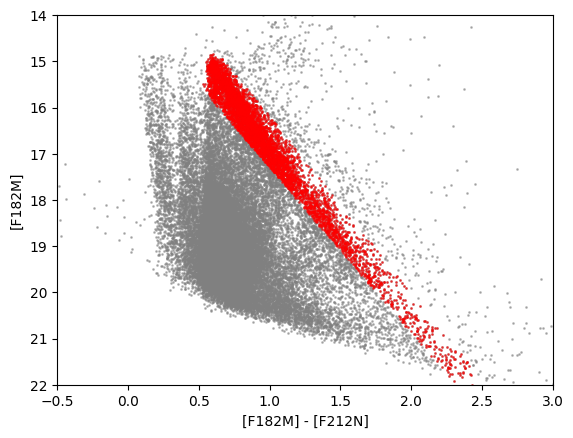

In [20]:
cat_brick.plot_CMD('f182m', 'f212n', 'f182m', color='grey', alpha=0.5, s=1)
cat_brick_rc.plot_CMD('f182m', 'f212n', 'f182m', color='red', alpha=0.5, s=1)
plt.xlim(-0.5, 3)
plt.ylim(22, 14)

In [21]:
reg_brick_north = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_north.reg')
reg_brick_south = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_south.reg')
reg_brick_head = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_head.reg')
reg_brick_sfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfluff.reg')
reg_brick_nfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nfluff.reg')
reg_brick_sfr = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr_tight.reg')
reg_brick_sfrwide = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr.reg')
reg_brick_punch = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_punch.reg')
reg_brick_sfore = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfore.reg')
reg_brick_nclear = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nclear.reg')
reg_brick_topc = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_topc.reg')


In [22]:
fn_brick = '/orange/adamginsburg/jwst/brick/F405N/pipeline/jw02221-o001_t001_nircam_clear-f405n-merged_i2d.fits'
hdu_brick = fits.open(fn_brick)
ww_brick = WCS(hdu_brick['SCI'].header)
nanfield_brick = np.nan * hdu_brick['SCI'].data

In [23]:
cat_brick_north = JWSTCatalog(cat_brick.table_region_mask(reg_brick_north, ww_brick)) #  
cat_brick_south = JWSTCatalog(cat_brick.table_region_mask(reg_brick_south, ww_brick))
cat_brick_head = JWSTCatalog(cat_brick.table_region_mask(reg_brick_head, ww_brick))
cat_brick_sfluff = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfluff, ww_brick))
cat_brick_nfluff = JWSTCatalog(cat_brick.table_region_mask(reg_brick_nfluff, ww_brick))
cat_brick_sfr = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfr, ww_brick))
cat_brick_sfrwide = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfrwide, ww_brick))
cat_brick_punch = JWSTCatalog(cat_brick.table_region_mask(reg_brick_punch, ww_brick))
cat_brick_sfore = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfore, ww_brick))
cat_brick_nclear = JWSTCatalog(cat_brick.table_region_mask(reg_brick_nclear, ww_brick))
cat_brick_topc = JWSTCatalog(cat_brick.table_region_mask(reg_brick_topc, ww_brick))


In [24]:
cat_brick_north_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_north, ww_brick)) #  
cat_brick_south_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_south, ww_brick))
cat_brick_head_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_head, ww_brick))
cat_brick_sfluff_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfluff, ww_brick))
cat_brick_nfluff_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_nfluff, ww_brick))
cat_brick_sfr_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfr, ww_brick))
cat_brick_sfrwide_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfrwide, ww_brick))
cat_brick_punch_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_punch, ww_brick))
cat_brick_sfore_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfore, ww_brick))
cat_brick_nclear_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_nclear, ww_brick))
cat_brick_topc_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_topc, ww_brick))

catalogs_brick = [cat_brick_north_rc, cat_brick_south_rc, cat_brick_head_rc, cat_brick_sfluff_rc, cat_brick_nfluff_rc, cat_brick_sfr_rc, cat_brick_sfrwide_rc, cat_brick_punch_rc, cat_brick_sfore_rc, cat_brick_nclear_rc, cat_brick_topc_rc]
labels_brick = ['Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick SFR', 'Brick SFR Wide', 'Brick Punch', 'Brick S Fore', 'Brick N Clear', 'Brick Top C']
colors_brick = ['red', 'blue', 'green', 'cyan', 'magenta', 'purple', 'brown', 'orange', 'pink', 'k', 'gray']


Brick South: multiple intersections found at [18.63932017 25.97864367], using the one between the two peaks
Brick South Fluff: multiple intersections found at [19.93761468 24.26037829], using the one between the two peaks
Brick S Fore: one of the gaussians has a negative amplitude, skipping intersection and high Av calculation


/scratch/local/31455051/ipykernel_3450433/2197089982.py:25: OptimizeWarning: Covariance of the parameters could not be estimated
  params, cov = curve_fit(bimodal, x, y, expected)


Brick S Fore: no intersection found from bimodal fit, trying single gaussian fit


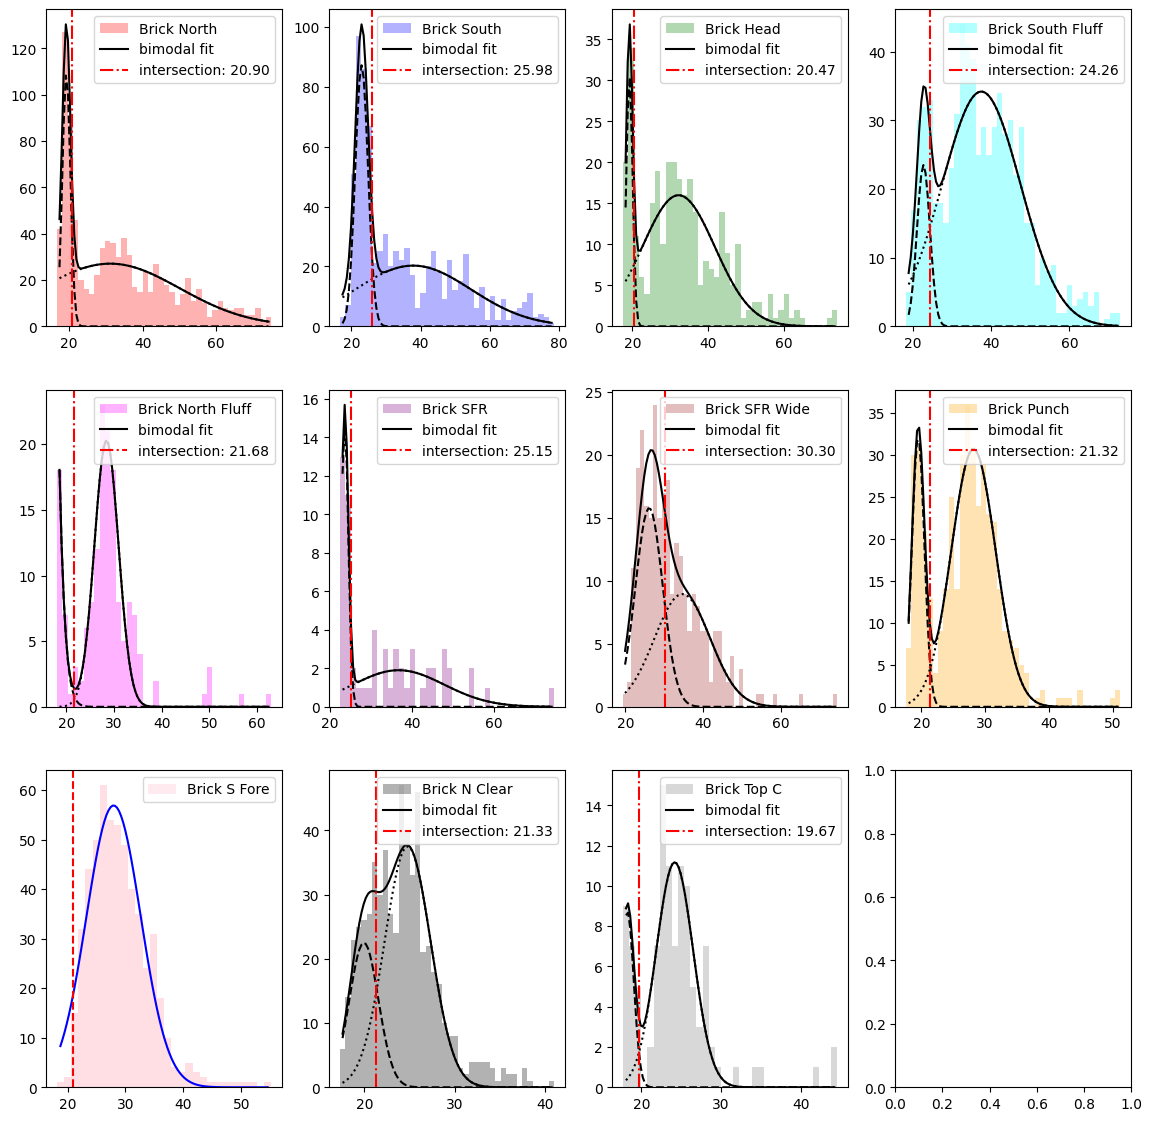

In [25]:
fig, axes = plt.subplots(3, 4, figsize=[14,14])#, sharex=True)
intersections_brick = []
highAv_brick = []

for i in range(11):
    ax = axes.flatten()[i]
    cat = catalogs_brick[i]
    data = cat.catalog['Av'].flatten()
    label = labels_brick[i]
    bin_num = starting_params[label][0]
    y,x,_=ax.hist(data, bin_num, alpha=.3, label=label, color=colors_brick[i])
    x=(x[1:]+x[:-1])/2

    mu1_guess = starting_params[label][1]
    sigma1_guess = starting_params[label][2]
    A1_guess = starting_params[label][3]

    mu2_guess = starting_params[label][4]
    sigma2_guess = starting_params[label][5]
    A2_guess = starting_params[label][6]

    expected = (mu1_guess, sigma1_guess, A1_guess, mu2_guess, sigma2_guess, A2_guess)

    try: 
        params, cov = curve_fit(bimodal, x, y, expected)
    except:
        print(f"{labels_brick[i]}: failed to fit bimodal")
        intersections_brick.append(np.nan)
        highAv_brick.append(np.nan)
        ax.legend(loc='upper right')
        continue
    if params[2] < 0 or params[5] < 0:
        print(f"{labels_brick[i]}: one of the gaussians has a negative amplitude, skipping intersection and high Av calculation")
        intersections_brick.append(np.nan)
        highAv_brick.append(np.nan)
        ax.legend(loc='upper right')
        continue

    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = bimodal(x_fit, *params)
    ax.plot(x_fit, y_fit, color='k', label='bimodal fit')
    ax.plot(x_fit, gauss(x_fit, *params[:3]), color='k', linestyle='--')
    ax.plot(x_fit, gauss(x_fit, *params[3:6]), color='k', linestyle=':')

    intersection = get_intersection_locations(gauss(x_fit, *params[:3]), gauss(x_fit, *params[3:6]), x=x_fit)
    intersection = x_fit[intersection]

    too_close = 1

    # if the intersection is too close to the mean of either gaussian, then it is likely not a real intersection and we should use the minimum between the two peaks as the intersection, and set high Av to be the mean + 2 sigma of the second gaussian
    if len(intersection) == 1:
        if np.logical_or(np.logical_and(intersection < params[0]+too_close, intersection > params[0]-too_close), np.logical_and(intersection < params[3]+too_close, intersection > params[3]-too_close)):
            print(f"{labels_brick[i]}: intersection at {intersection} is too close to the mean of either gaussian, trying to find minimum of bimodal fit")
            minima, _ = find_peaks(-y_fit)
            if len(minima) == 0:
                print(f"{labels_brick[i]}: no minimum found, skipping intersection and high Av calculation")
                intersections_brick.append(np.nan)
                highAv_brick.append(np.nan)
                ax.legend(loc='upper right')
                continue
            else:
                print(f"{labels_brick[i]}: minimum found at {x_fit[minima]}, using that as the intersection")
                intersections_brick.append(x_fit[minima][0])
                highAv_brick.append(params[3]+2*params[4]) # mean + 2 sigma of the second gaussian, which should correspond to the high Av population
        else: 
            intersections_brick.append(intersection[0])
            highAv_brick.append(params[3]+2*params[4]) # mean + 2 sigma of the second gaussian, which should correspond to the high Av population
    elif len(intersection) == 2:
        # if either of the two intersections is too close to the mean
        # then use the minimum between the two peaks as the intersection, and set high Av to be the mean + 2 sigma of the second gaussian
        if np.logical_or(np.logical_and(intersection[0] < params[0]+too_close, intersection[0] > params[0]-too_close), np.logical_and(intersection[0] < params[3]+too_close, intersection[0] > params[3]-too_close)):
            print(f"{labels_brick[i]}: intersection at {intersection[0]} is too close to the mean of either gaussian, trying to find minimum of bimodal fit")
            minima, _ = find_peaks(-y_fit)
            if len(minima) == 0:
                print(f"{labels_brick[i]}: no minimum found, skipping intersection and high Av calculation")
                intersections_brick.append(np.nan)
                highAv_brick.append(np.nan)
                ax.legend(loc='upper right')
                continue
            else:
                print(f"{labels_brick[i]}: minimum found at {x_fit[minima]}, using that as the intersection")
                intersections_brick.append(x_fit[minima][0])
                highAv_brick.append(params[3]+2*params[4]) # mean + 2 sigma of the second gaussian, which should correspond to the high Av population
        elif np.logical_or(np.logical_and(intersection[1] < params[0]+too_close, intersection[1] > params[0]-too_close), np.logical_and(intersection[1] < params[3]+too_close, intersection[1] > params[3]-too_close)):
            print(f"{labels_brick[i]}: intersection at {intersection[1]} is too close to the mean of either gaussian, trying to find minimum of bimodal fit")
            minima, _ = find_peaks(-y_fit)
            if len(minima) == 0:
                print(f"{labels_brick[i]}: no minimum found, skipping intersection and high Av calculation")
                intersections_brick.append(np.nan)
                highAv_brick.append(np.nan)
                ax.legend(loc='upper right')
                continue
            else:
                print(f"{labels_brick[i]}: minimum found at {x_fit[minima]}, using that as the intersection")
                intersections_brick.append(x_fit[minima][0])
                highAv_brick.append(params[3]+2*params[4]) # mean + 2 sigma of the second gaussian, which should correspond to the high Av population
        else: 
            print(f"{labels_brick[i]}: multiple intersections found at {intersection}, using the one between the two peaks")
            if params[0] < params[3]: # if the first gaussian has a smaller mean than the second gaussian
                if np.logical_and(intersection[0] > params[0], intersection[0] < params[3]):
                    intersections_brick.append(intersection[0])
                elif np.logical_and(intersection[1] > params[0], intersection[1] < params[3]):
                    intersections_brick.append(intersection[1])
            elif params[0] > params[3]:
                if np.logical_and(intersection[0] > params[3], intersection[0] < params[0]):
                    intersections_brick.append(intersection[0])
                elif np.logical_and(intersection[1] > params[3], intersection[1] < params[0]):
                    intersections_brick.append(intersection[1])
            highAv_brick.append(params[3]+2*params[4]) # mean + 2 sigma of the second gaussian, which should correspond to the high Av population
    elif len(intersection) == 0:
        print(f"{labels_brick[i]}: no intersection found, trying to find minimum of bimodal fit")
        minima, _ = find_peaks(-y_fit)
        if len(minima) == 0:
            print(f"{labels_brick[i]}: no minimum found, skipping intersection and high Av calculation")
            intersections_brick.append(np.nan)
            highAv_brick.append(np.nan)
            ax.legend(loc='upper right')
            continue
        else:
            print(f"{labels_brick[i]}: minimum found at {x_fit[minima]}, using that as the intersection")
            intersections_brick.append(x_fit[minima][0])
            highAv_brick.append(params[3]+2*params[4]) # mean + 2 sigma of the second gaussian, which should correspond to the high Av population
    
    ax.axvline(intersections_brick[-1], color='r', linestyle='-.', label=f'intersection: {intersections_brick[-1]:.2f}')


    ax.legend(loc='upper right')

for i in range(11):
    intersection = intersections_brick[i]
    ax = axes.flatten()[i]
    if intersection == -1:
        # fit with a bimodial and use the location of the minimum between the two peaks as the intersection, and set high Av to be the mean + 2 sigma of the second gaussian
        continue
    elif ~np.isnan(intersection):
        continue
    else:
        # fit with a single gaussian and use the mean + 2 sigma as the high Av
        print(f"{labels_brick[i]}: no intersection found from bimodal fit, trying single gaussian fit")
        label = labels_brick[i]
        mu_guess = starting_params[label][1]
        sigma_guess = starting_params[label][2]
        A_guess = starting_params[label][3]
        expected = (mu_guess, sigma_guess, A_guess)
        cat = catalogs_brick[i]
        data = cat.catalog['Av'].flatten()
        bin_num = starting_params[label][0]
        if label in ['Left Cloud D']:
            bins = np.linspace(18, 40, bin_num)
            y,x_bins,_= ax.hist(data, bins=bins, alpha=.3, label=label, color=colors_brick[i])
        else:
            y,x_bins,_ = ax.hist(data, bins=starting_params[label][0], alpha=.3, label=label, color=colors_brick[i])
        x = (x_bins[1:] + x_bins[:-1]) / 2
        try:
            params, cov = curve_fit(gauss, x, y, expected)
        except:
            print(f"{labels_brick[i]}: failed to fit single gaussian")
            intersections_brick[i] = np.nan
            highAv_brick[i] = np.nan
            continue
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = gauss(x_fit, *params)
        ax.plot(x_fit, y_fit, color='b', label='gaussian fit')
        ax.axvline(params[0]-1.5*params[1], color='r', linestyle='--')#, label=f'gaussian mean - sigma: {params[0]-1.5*params[1]:.2f}')
        intersections_brick[i] = params[0]-1.5*params[1]

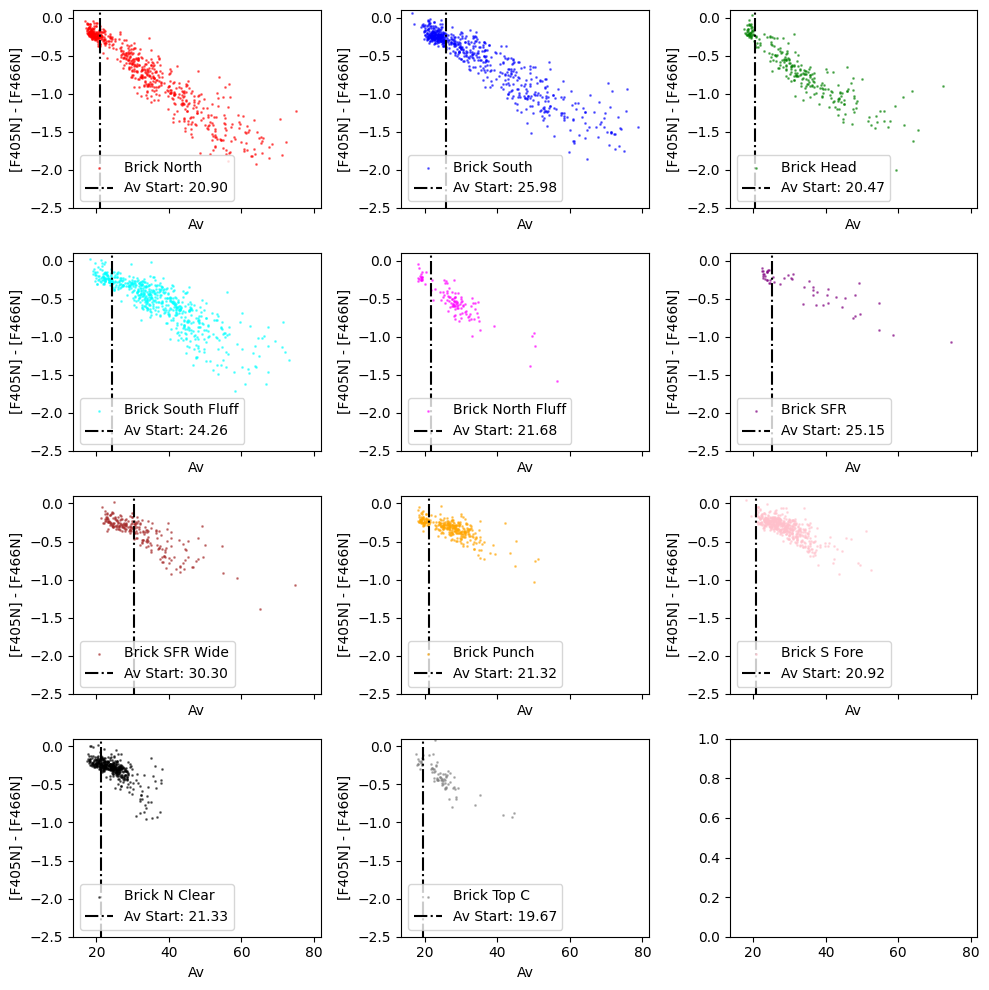

In [26]:
fig, axes = plt.subplots(4, 3, figsize=[10,10], sharex=True)

for i in range(11):
    ax = axes.flatten()[i]
    cat = catalogs_brick[i]

    ax.scatter(cat.catalog['Av'], cat.color('f405n', 'f466n'), color=colors_brick[i], label=labels_brick[i], alpha=0.5, s=1)
    try:
        ax.axvline(intersections_brick[i], color='k', linestyle='-.', label=f'Av Start: {intersections_brick[i]:.2f}')
    except:
        print(f"{labels_brick[i]}: no intersection to plot")
    ax.set_ylim(-2.5, 0.1)

    ax.legend(loc='lower left')
    ax.set_xlabel('Av')
    ax.set_ylabel('[F405N] - [F466N]')

plt.tight_layout()

# Fitting with new Av starts

Filament: slope = -0.51 ± 0.02
Cloud C1: slope = -0.90 ± 0.04
Cloud C2: slope = -0.92 ± 0.04
Cloud D: slope = -0.97 ± 0.03
Cloud B: slope = -1.13 ± 0.05
Filament Right: slope = -1.05 ± 0.04
Left Cloud D: slope = -0.98 ± 0.06
Cloud C North: slope = -0.93 ± 0.06
Cloud C South: slope = -1.02 ± 0.05
Brick North: slope = -1.04 ± 0.03
Brick South: slope = -0.86 ± 0.03
Brick Head: slope = -0.83 ± 0.06
Brick South Fluff: slope = -0.82 ± 0.03
Brick North Fluff: slope = -0.93 ± 0.11
Brick SFR: slope = -0.58 ± 0.07
Brick SFR Wide: slope = -0.67 ± 0.09
Brick Punch: slope = -0.60 ± 0.07
Brick S Fore: slope = -0.65 ± 0.04
Brick N Clear: slope = -0.89 ± 0.10
Brick Top C: slope = -0.99 ± 0.10


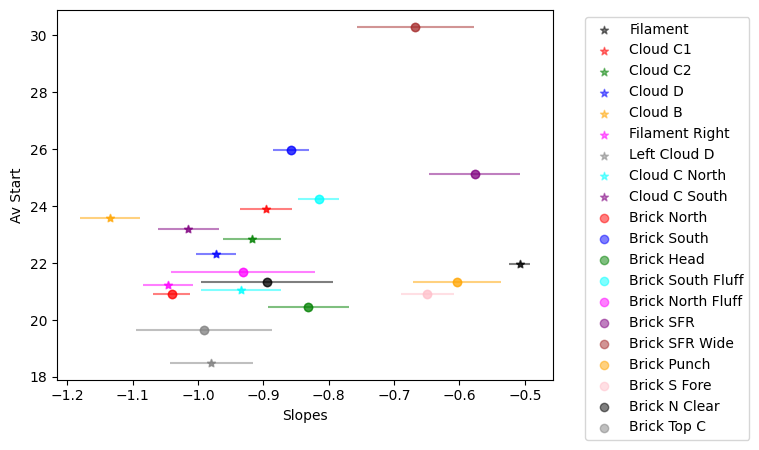

In [27]:
combined_catalogs = catalogs_cloudc + catalogs_brick
combined_labels = labels_cloudc + labels_brick
combined_colors = colors_cloudc + colors_brick
combined_intersections = intersections_cloudc + intersections_brick
combined_highAv = highAv_cloudc + highAv_brick

rang = np.linspace(0.5, 2.7, 100)
combined_slopes = []
combined_slopes_std = []

ax = plt.subplot(111)

for i in range(len(combined_catalogs)):
    cat = combined_catalogs[i]
    av_start = combined_intersections[i]
    if np.isnan(av_start):
        av_start = np.nanmin(cat.catalog['Av'])
    cat = JWSTCatalog(cat.catalog[cat.catalog['Av'] > av_start])
    x = cat.color('f182m', 'f212n')
    y = cat.color('f405n', 'f466n')
    slopes = []

    for j in range(100):
        indices = np.random.choice(len(x), len(x), replace=True)
        x_boot = x[indices]
        y_boot = y[indices]

        fit = fitting.LinearLSQFitter()
        line_boot = fit(models.Linear1D(), x_boot, y_boot)
        slopes.append(line_boot.slope.value)

    slope_mean = np.mean(slopes)
    slope_std = np.std(slopes)
    combined_slopes.append(slope_mean)
    combined_slopes_std.append(slope_std)
    print(f"{combined_labels[i]}: slope = {slope_mean:.2f} ± {slope_std:.2f}")

    marker = 'o' if 'Brick' in combined_labels[i] else '*'
    ax.errorbar(slope_mean, av_start, xerr=slope_std, color=combined_colors[i], alpha=0.5, marker=marker, linestyle='None')
    ax.scatter(slope_mean, av_start, color=combined_colors[i], label=combined_labels[i], alpha=0.5, marker=marker)

ax.set_xlabel('Slopes')
ax.set_ylabel('Av Start')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Ice Models

In [28]:
mixes = [
    #('H2O:CO:CO2 (1:1:1)', 25.0),
    #('H2O:CO:CO2 (3:1:0.5)', 25.0),
    #('H2O:CO:CO2 (2:1:1)', 25.0),
    #('H2O:CO:CO2 (3:1:1)', 25.0),
    #('H2O:CO:CO2 (5:1:1)', 25.0),
    ('H2O:CO:CO2 (10:1:1)', 25.0),
    ('H2O:CO:CO2 (10:1:0.5)', 25.0),
    ('H2O:CO:CO2 (15:1:1)', 25.0),
    ('H2O:CO:CO2 (20:1:1)', 25.0),
    # ('H2O:CO (1:1)', 25.0),
    # ('H2O:CO (3:1)', 25.0),
    # ('H2O:CO (5:1)', 25.0),
    # ('H2O:CO (10:1)', 25.0),
    # ('H2O:CO (15:1)', 25.0),
    # ('H2O:CO (20:1)', 25.0),
    #('H2O:CO:CO2:CH3OH (1:1:1:1)', 25.0),
    #('H2O:CO:CO2:CH3OH:CH3CH2OH (1:1:1:1:1)', 25.0),
]

In [29]:
tbl = co_map.get_dmag_tbl()
dmag_tbl = tbl
dmag_tbl.add_index('temperature')
tbl.add_index('database')
tbl.add_index('column')

In [30]:
single_plot = [{
        'color1': ['F182M', 'F212N'],
        'color2': ['F405N', 'F466N'],
        'axlims': (0, 3, -3, 0.5),
        'molcomps': [('H2O:CO:CO2 (20:1:1)', 25.0)],
        'abundance_wrt_h2': 1.6e-4,#2.5e-4, #(percent_ice/100.)*carbon_abundance,
        'max_column': 5e22,
        'avstart': 17.0,
    }]
plot_params = single_plot[0]

`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]
`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]
`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]
`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]
`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]
`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index_id)[item]`.
 [astropy.table.index]
`index_id` is deprecated. Instead select the index using the syntax
`Table.loc/iloc/loc_indices.with_index(index

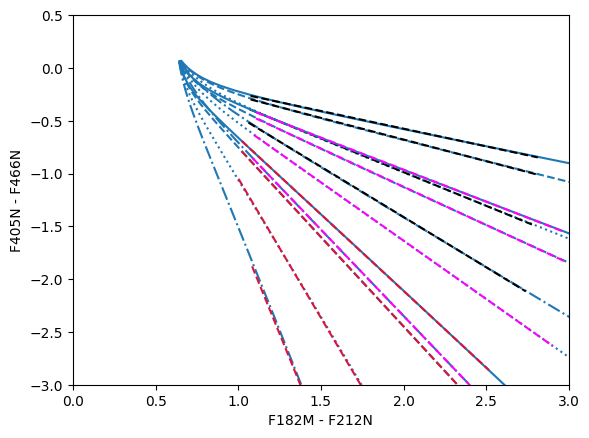

In [31]:
#slopes_ = []
#intercepts_ = []
abundances = [1.6e-4, 2.5e-4, 5e-4]
starts = [20]

model_slopes = {}

for i in range(len(abundances)):
    for mix in mixes:
        for s in starts:
            plot_params['molcomps'] = [mix]
            a_color1, a_color2, c1, c2, sel, E_V_color1, E_V_color2, tb = plot_ccd_icemodels(
                        color1=plot_params['color1'],
                        color2=plot_params['color2'],
                        dmag_tbl=dmag_tbl,
                        molcomps=plot_params['molcomps'],
                        axlims=plot_params['axlims'],
                        #icemol=plot_params['icemol'],
                        abundance_wrt_h2=abundances[i],
                        max_column=plot_params['max_column'], 
                        color='tab:blue',
                        av_start = s
                    )
            
            sel = (c1 > 1) & (c1 < 3)
            fit = fitting.LinearLSQFitter()
            line_init = models.Linear1D()
            fitted_line = fit(line_init, c1[sel], c2[sel])
            
            model_slopes[(mix[0], s, abundances[i])] = fitted_line.slope.value
            if i == 0:
                color = 'k'
            elif i == 1:
                color = 'magenta'
            elif i == 2:
                color = 'crimson'
            
            plt.plot(c1[sel], fitted_line(c1[sel]), linestyle='--', label=f'{mix[0]} slope={fitted_line.slope.value:.2f}', color=color)



In [32]:
from dust_extinction.averages import CT06_MWGC, CT06_MWLoc

def color2av(color):
    ext = CT06_MWGC()
    av = color / (ext(1.87*u.micron) - ext(2.12*u.micron))
    return av

def av2color(av):
    ext = CT06_MWGC()
    color = av * (ext(1.87*u.micron) - ext(2.12*u.micron))
    return color

Filament: slope = -0.51 ± 0.01
Cloud C1: slope = -0.90 ± 0.04
Cloud C2: slope = -0.92 ± 0.05
Cloud D: slope = -0.97 ± 0.03
Cloud B: slope = -1.13 ± 0.05
Filament Right: slope = -1.04 ± 0.04
Left Cloud D: slope = -0.98 ± 0.07
Cloud C North: slope = -0.93 ± 0.06
Cloud C South: slope = -1.04 ± 0.05
Brick North: slope = -1.04 ± 0.03
Brick South: slope = -0.85 ± 0.03
Brick Head: slope = -0.85 ± 0.08
Brick South Fluff: slope = -0.81 ± 0.03
Brick North Fluff: slope = -0.95 ± 0.10
Brick SFR: slope = -0.57 ± 0.07
Brick SFR Wide: slope = -0.67 ± 0.07
Brick Punch: slope = -0.61 ± 0.06
Brick S Fore: slope = -0.65 ± 0.04
Brick N Clear: slope = -0.91 ± 0.09
Brick Top C: slope = -1.00 ± 0.13


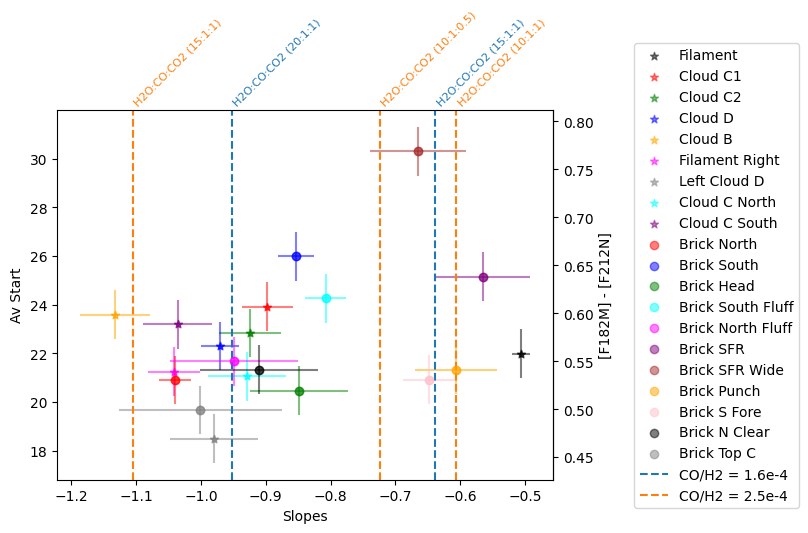

In [33]:
combined_catalogs = catalogs_cloudc + catalogs_brick
combined_labels = labels_cloudc + labels_brick
combined_colors = colors_cloudc + colors_brick
combined_intersections = intersections_cloudc + intersections_brick

rang = np.linspace(0.5, 2.7, 100)
combined_slopes = []
combined_slopes_std = []

ax = plt.subplot(111)

for i in range(len(combined_catalogs)):
    cat = combined_catalogs[i]
    av_start = combined_intersections[i]
    if np.isnan(av_start):
        av_start = np.nanmean(cat.catalog['Av'])-2*np.nanstd(cat.catalog['Av'])
        #np.nanmin(cat.catalog['Av'])
    cat = JWSTCatalog(cat.catalog[cat.catalog['Av'] > av_start])
    x = cat.color('f182m', 'f212n')
    y = cat.color('f405n', 'f466n')
    slopes = []

    for j in range(100):
        indices = np.random.choice(len(x), len(x), replace=True)
        x_boot = x[indices]
        y_boot = y[indices]

        fit = fitting.LinearLSQFitter()
        line_boot = fit(models.Linear1D(), x_boot, y_boot)
        slopes.append(line_boot.slope.value)

    slope_mean = np.mean(slopes)
    slope_std = np.std(slopes)
    combined_slopes.append(slope_mean)
    combined_slopes_std.append(slope_std)
    print(f"{combined_labels[i]}: slope = {slope_mean:.2f} ± {slope_std:.2f}")

    marker = 'o' if 'Brick' in combined_labels[i] else '*'
    ax.errorbar(slope_mean, av_start, xerr=slope_std, yerr=1, color=combined_colors[i], alpha=0.5, marker=marker, linestyle='None')
    ax.scatter(slope_mean, av_start, color=combined_colors[i], label=combined_labels[i], alpha=0.5, marker=marker)

for i in range(len(abundances)):
    j = 0
    for mix in mixes:
        for s in starts:
            slope = model_slopes[(mix[0], s, abundances[i])]
            if i == 0:
                color = 'tab:blue'
                label = 'CO/H2 = 1.6e-4'
            elif i == 1:
                color = 'tab:orange'
                label = 'CO/H2 = 2.5e-4'
            elif i == 2:
                color = 'tab:green'
                label = 'CO/H2 = 5.0e-4'
            if slope < ax.get_xlim()[0] or slope > ax.get_xlim()[1]:
                continue
            if j > 0:
                label = None
            j += 1
            plt.axvline(slope, linestyle='--', color=color, label=label)
            plt.text(slope, ax.get_ylim()[1]+0.1, f'{mix[0]}', rotation=45, verticalalignment='bottom', color=color, fontsize=8)


ax.set_xlabel('Slopes')
ax.set_ylabel('Av Start')
ax.legend(bbox_to_anchor=(1.15, 1.2), loc='upper left')
#ax.set_xlim(-1.2, -0.45)

secay = ax.secondary_yaxis('right', functions=(av2color, color2av))
secay.set_ylabel('[F182M] - [F212N]')

plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/av_start_vs_slope.png', bbox_inches='tight', dpi=300)
plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/av_start_vs_slope.pdf', bbox_inches='tight')
#plt.tight_layout()

/scratch/local/31455051/ipykernel_3450433/4284910015.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
/scratch/local/31455051/ipykernel_3450433/4284910015.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
/scratch/local/31455051/ipykernel_3450433/4284910015.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
/scratch/local/31455051/ipykernel_3450433/4284910015.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
/scratch/local/31455051/i

Filament: slope = -0.51 ± 0.02
Cloud C1: slope = -0.90 ± 0.04
Cloud C2: slope = -0.92 ± 0.05
Cloud D: slope = -0.98 ± 0.03
Cloud B: slope = -1.13 ± 0.06
Filament Right: slope = -1.04 ± 0.04
Left Cloud D: slope = -0.97 ± 0.06
Cloud C North: slope = -0.94 ± 0.07
Cloud C South: slope = -1.02 ± 0.05
Brick North: slope = -1.04 ± 0.03
Brick South: slope = -0.85 ± 0.02
Brick Head: slope = -0.85 ± 0.06
Brick South Fluff: slope = -0.81 ± 0.03
Brick North Fluff: slope = -0.93 ± 0.10
Brick SFR: slope = -0.57 ± 0.07
Brick SFR Wide: slope = -0.67 ± 0.08
Brick Punch: slope = -0.61 ± 0.07
Brick S Fore: slope = -0.65 ± 0.04
Brick N Clear: slope = -0.93 ± 0.10
Brick Top C: slope = -0.98 ± 0.09


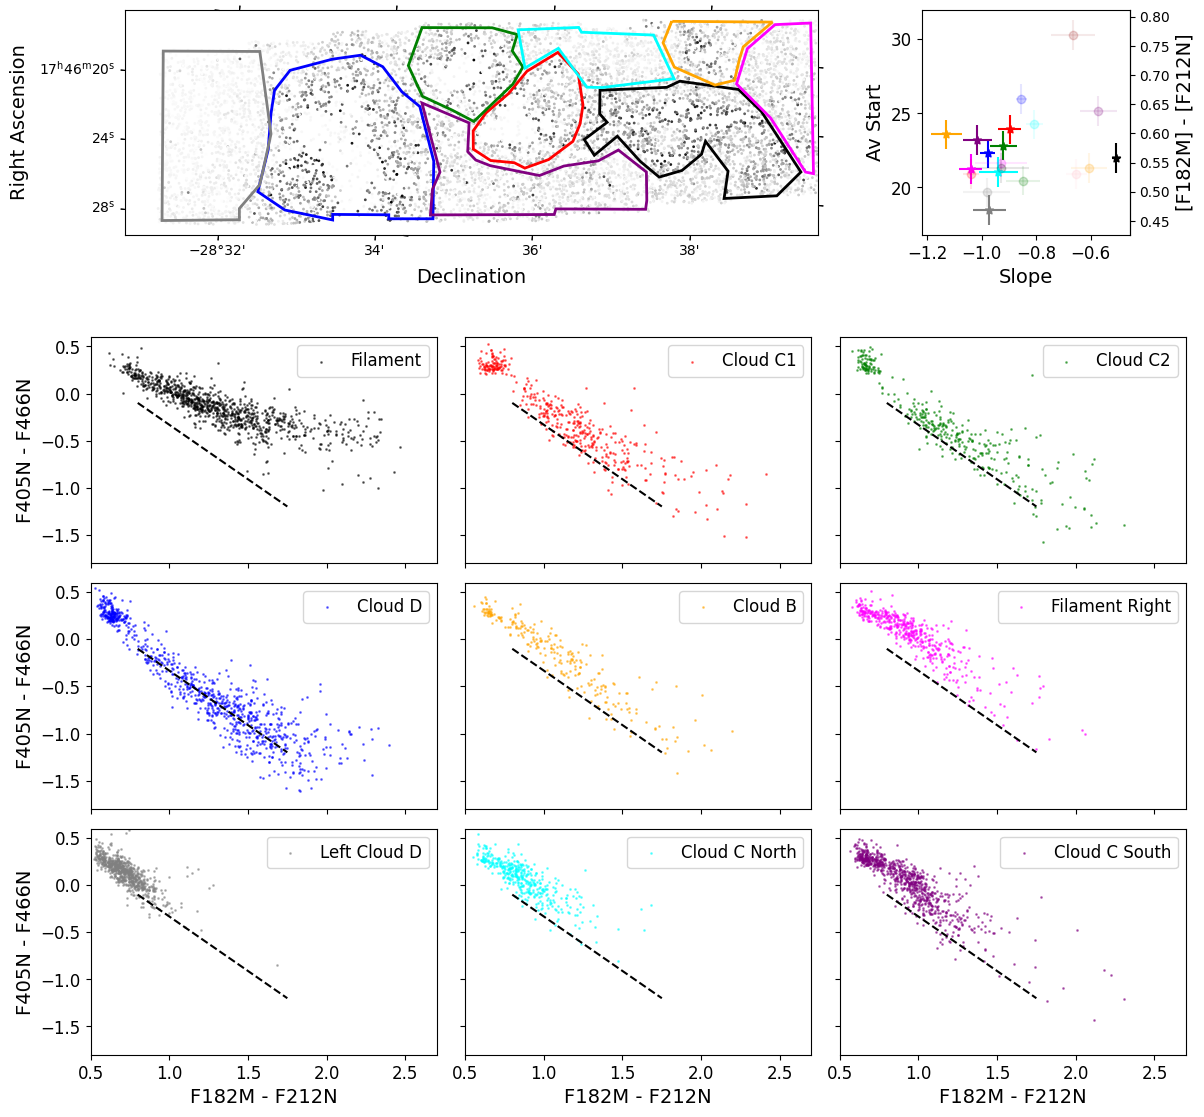

In [34]:
fig, axes = plt.subplots(3, 3, figsize=(12,8), sharex=True, sharey=True)

for i in range(len(catalogs_cloudc)):
    cat = catalogs_cloudc[i]
    ax = axes.flatten()[i]
    cat.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', ax=ax, s=1, alpha=0.5, label=labels_cloudc[i], color=colors_cloudc[i])
    if i > 5:
        ax.set_xlabel('F182M - F212N', fontsize=14)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
    else: 
        ax.set_xlabel('')
    if i % 3 == 0:
        ax.set_ylabel('F405N - F466N', fontsize=14)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    else: 
        ax.set_ylabel('')
    ax.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
    ax.legend(fontsize=12)
    ax.set_xlim(0.5, 2.7)
    ax.set_ylim(-2.3, 0.1)


plt.tight_layout()

ax = axes.flatten()[0].inset_axes([0.1, 1.2, 2, 1.5], projection=ww) #plt.subplot(411, projection=ww)
ax.imshow(nanfield)
im = ax.scatter(cat_rc.ra, cat_rc.dec, c=cat_rc.color('f182m', 'f212n'), s=1, cmap='Greys', transform=ax.get_transform('world'))
#im = cat_rc.plot_position(s=1, c=cat_rc.color('f182m', 'f212n'), cmap='Greys', transform=ax.get_transform('world'))
#cax = ax.inset_axes([1.01, 0., 0.03, 1])
#cbar = plt.colorbar(im, cax=cax, orientation='vertical')
#cbar.set_label('[F182M] - [F212N]', fontsize=10)
ax.set_xlabel('Declination', fontsize=14)
ax.set_ylabel('Right Ascension', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)

reg_f[0].to_pixel(ww).plot(ax=ax, edgecolor='k', facecolor='none', lw=2)
reg_c1[0].to_pixel(ww).plot(ax=ax, edgecolor='r', facecolor='none', lw=2)
reg_c2[0].to_pixel(ww).plot(ax=ax, edgecolor='g', facecolor='none', lw=2)
reg_d[0].to_pixel(ww).plot(ax=ax, edgecolor='b', facecolor='none', lw=2)
reg_b[0].to_pixel(ww).plot(ax=ax, edgecolor='orange', facecolor='none', lw=2)
reg_fil_r[0].to_pixel(ww).plot(ax=ax, edgecolor='magenta', facecolor='none', lw=2)
reg_left_cd[0].to_pixel(ww).plot(ax=ax, edgecolor='grey', facecolor='none', lw=2)
reg_c_s[0].to_pixel(ww).plot(ax=ax, edgecolor='purple', facecolor='none', lw=2)
reg_c_n[0].to_pixel(ww).plot(ax=ax, edgecolor='cyan', facecolor='none', lw=2)

ax2 = ax.inset_axes([1.15, 0, 0.3, 1])

for i in range(len(combined_catalogs)):
    cat = combined_catalogs[i]
    av_start = combined_intersections[i]
    if np.isnan(av_start):
        av_start = np.nanmin(cat.catalog['Av'])
    cat = JWSTCatalog(cat.catalog[cat.catalog['Av'] > av_start])
    x = cat.color('f182m', 'f212n')
    y = cat.color('f405n', 'f466n')
    slopes = []

    for j in range(100):
        indices = np.random.choice(len(x), len(x), replace=True)
        x_boot = x[indices]
        y_boot = y[indices]

        fit = fitting.LinearLSQFitter()
        line_boot = fit(models.Linear1D(), x_boot, y_boot)
        slopes.append(line_boot.slope.value)

    slope_mean = np.mean(slopes)
    slope_std = np.std(slopes)
    combined_slopes.append(slope_mean)
    combined_slopes_std.append(slope_std)
    print(f"{combined_labels[i]}: slope = {slope_mean:.2f} ± {slope_std:.2f}")

    marker = 'o' if 'Brick' in combined_labels[i] else '*'
    alpha = 0.1 if 'Brick' in combined_labels[i] else 1
    ax2.errorbar(slope_mean, av_start, xerr=slope_std, yerr=1, color=combined_colors[i], alpha=alpha, marker=marker, linestyle='None')
    ax2.scatter(slope_mean, av_start, color=combined_colors[i], label=combined_labels[i], alpha=alpha, marker=marker)


ax2.set_xlabel('Slope', fontsize=14)
ax2.set_ylabel('Av Start', fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)

secay = ax2.secondary_yaxis('right', functions=(av2color, color2av))
secay.set_ylabel('[F182M] - [F212N]', fontsize=14)

plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/dustridge_rc_CCDs.png', dpi=300, bbox_inches='tight')
plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/dustridge_rc_CCDs.pdf', bbox_inches='tight')

/scratch/local/31455051/ipykernel_3450433/2810130996.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
/scratch/local/31455051/ipykernel_3450433/2810130996.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
/scratch/local/31455051/ipykernel_3450433/2810130996.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
/scratch/local/31455051/ipykernel_3450433/2810130996.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
/scratch/local/31455051/i

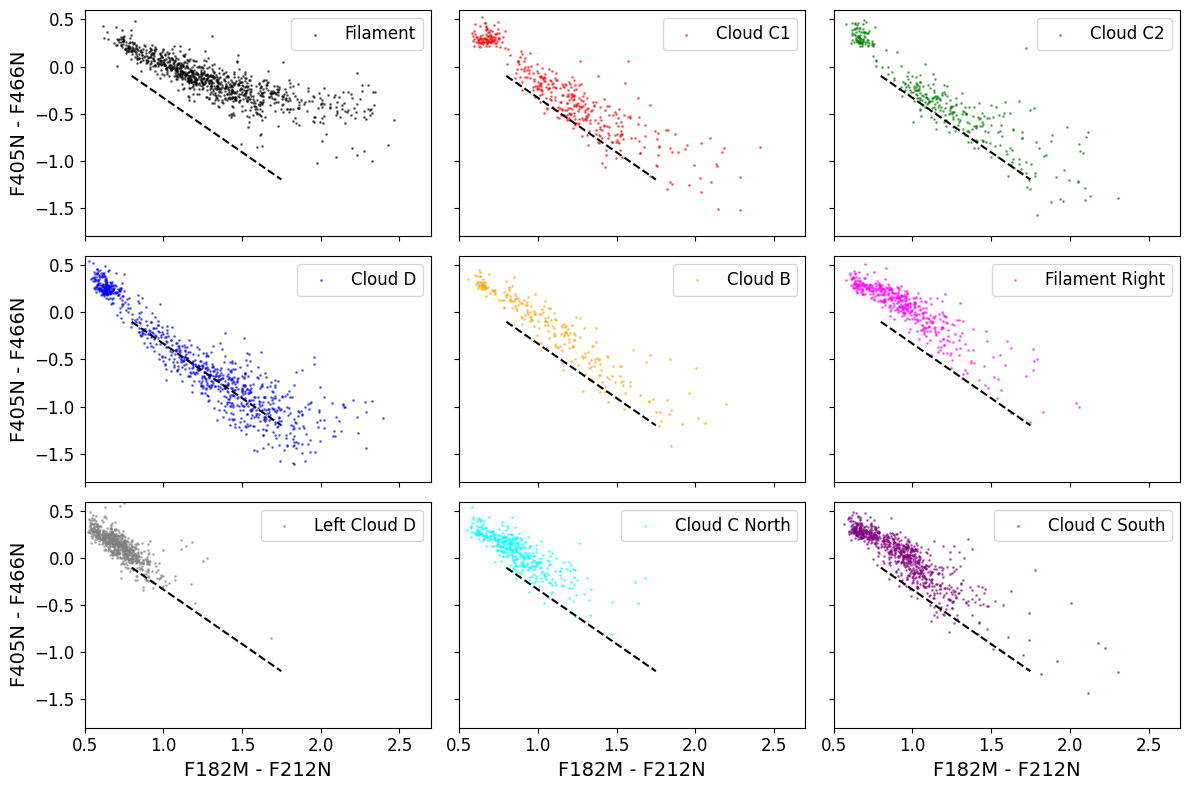

In [39]:
fig, axes = plt.subplots(3, 3, figsize=(12,8), sharex=True, sharey=True)

for i in range(len(catalogs_cloudc)):
    cat = catalogs_cloudc[i]
    ax = axes.flatten()[i]
    cat.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', ax=ax, s=1, alpha=0.5, label=labels_cloudc[i], color=colors_cloudc[i])
    if i > 5:
        ax.set_xlabel('F182M - F212N', fontsize=14)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
    else: 
        ax.set_xlabel('')
    if i % 3 == 0:
        ax.set_ylabel('F405N - F466N', fontsize=14)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    else: 
        ax.set_ylabel('')
    ax.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
    ax.legend(fontsize=12)
    ax.set_xlim(0.5, 2.7)
    ax.set_ylim(-2.3, 0.1)

plt.tight_layout()

plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/ccds_rc_cloudc.png', bbox_inches='tight', transparent=True, dpi=300)

Filament: slope = -0.51 ± 0.02
Cloud C1: slope = -0.89 ± 0.04
Cloud C2: slope = -0.92 ± 0.04
Cloud D: slope = -0.98 ± 0.03
Cloud B: slope = -1.12 ± 0.05
Filament Right: slope = -1.04 ± 0.04
Left Cloud D: slope = -0.98 ± 0.07
Cloud C North: slope = -0.92 ± 0.07
Cloud C South: slope = -1.02 ± 0.05
Brick North: slope = -1.04 ± 0.03
Brick South: slope = -0.86 ± 0.03
Brick Head: slope = -0.85 ± 0.07
Brick South Fluff: slope = -0.81 ± 0.03
Brick North Fluff: slope = -0.94 ± 0.08
Brick SFR: slope = -0.58 ± 0.07
Brick SFR Wide: slope = -0.67 ± 0.07
Brick Punch: slope = -0.61 ± 0.07
Brick S Fore: slope = -0.65 ± 0.04
Brick N Clear: slope = -0.90 ± 0.09
Brick Top C: slope = -0.99 ± 0.11


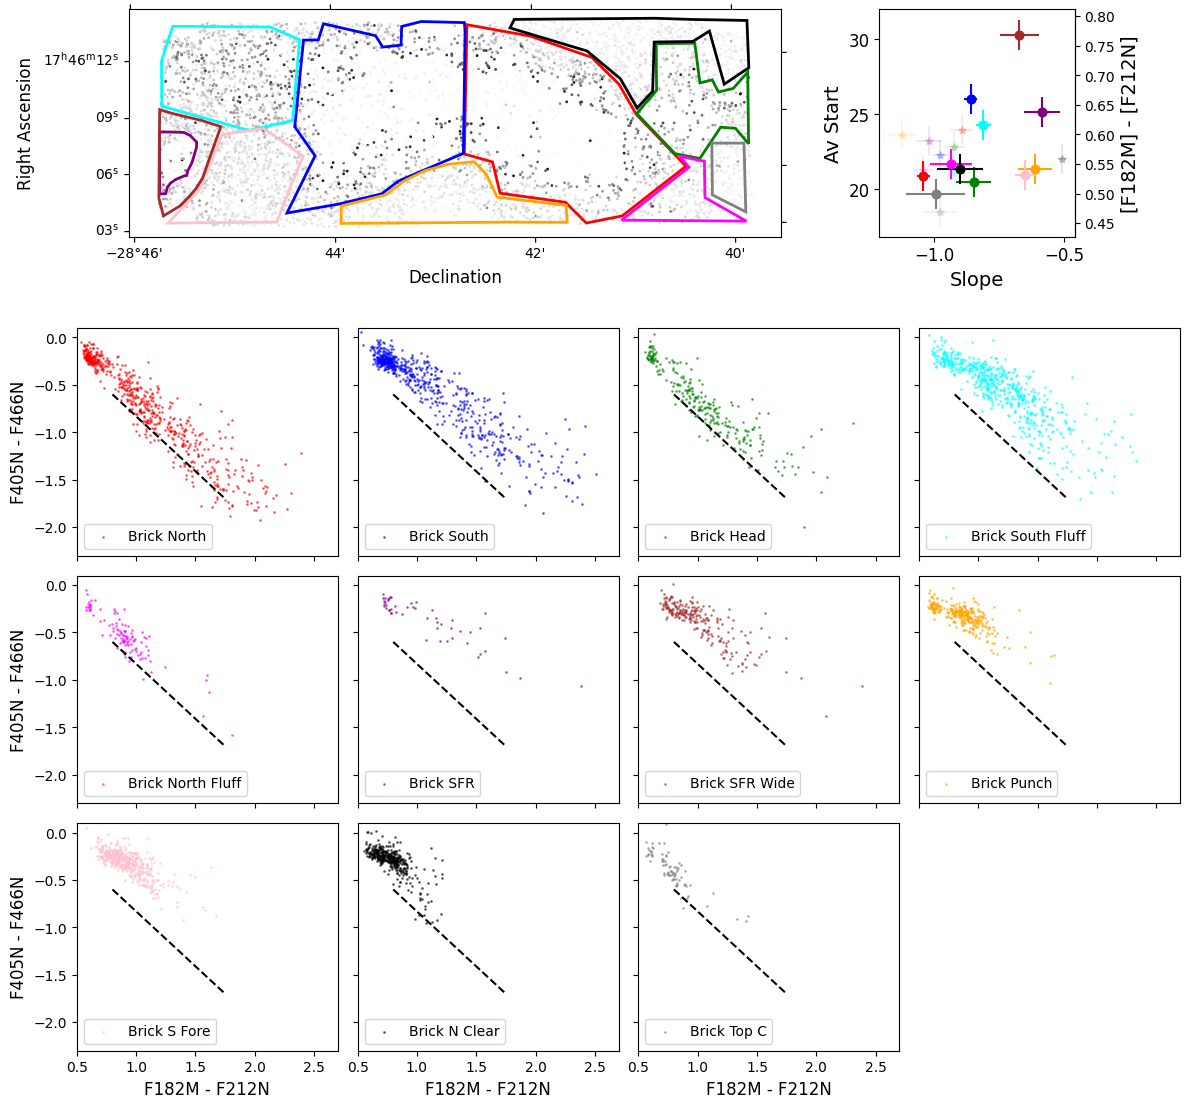

In [35]:
fig, axes = plt.subplots(3, 4, figsize=(12,8), sharex=True, sharey=True)

for i in range(len(catalogs_brick)):
    ax = axes.flatten()[i]
    cat = catalogs_brick[i]
    cat.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', ax=ax, s=1, alpha=0.5, label=labels_brick[i], color=colors_brick[i])
    if i > 7:
        ax.set_xlabel('F182M - F212N', fontsize=12)
    else: 
        ax.set_xlabel('')
    if i % 4 == 0:
        ax.set_ylabel('F405N - F466N', fontsize=12)
    else: 
        ax.set_ylabel('')
    ax.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
    ax.legend(loc='lower left')
    ax.set_xlim(0.5, 2.7)
    ax.set_ylim(-2.3, 0.1)

axes.flatten()[-1].axis('off')

plt.tight_layout()

ax = axes.flatten()[0].inset_axes([0.2, 1.4, 2.5, 1], projection=ww_brick)
plt.imshow(nanfield_brick)
cat_brick_rc.plot_position(ax=ax, transform=ax.get_transform('world'), s=1, cmap='Greys', c=cat_brick_rc.color('f182m', 'f212n'))
ax.set_xlabel('Declination', fontsize=12)
ax.set_ylabel('Right Ascension', fontsize=12)

reg_brick_north[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='red')
reg_brick_south[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='blue')
reg_brick_head[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='green')
reg_brick_sfluff[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='cyan')
reg_brick_nfluff[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='magenta')
reg_brick_sfr[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='purple')
reg_brick_punch[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='orange')
reg_brick_sfore[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='pink')
reg_brick_nclear[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='k')
reg_brick_topc[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='gray')
reg_brick_sfrwide[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='brown')

ax2 = ax.inset_axes([1.15, 0, 0.3, 1])

for i in range(len(combined_catalogs)):
    cat = combined_catalogs[i]
    av_start = combined_intersections[i]
    if np.isnan(av_start):
        av_start = np.nanmin(cat.catalog['Av'])
    cat = JWSTCatalog(cat.catalog[cat.catalog['Av'] > av_start])
    x = cat.color('f182m', 'f212n')
    y = cat.color('f405n', 'f466n')
    slopes = []

    for j in range(100):
        indices = np.random.choice(len(x), len(x), replace=True)
        x_boot = x[indices]
        y_boot = y[indices]

        fit = fitting.LinearLSQFitter()
        line_boot = fit(models.Linear1D(), x_boot, y_boot)
        slopes.append(line_boot.slope.value)

    slope_mean = np.mean(slopes)
    slope_std = np.std(slopes)
    combined_slopes.append(slope_mean)
    combined_slopes_std.append(slope_std)
    print(f"{combined_labels[i]}: slope = {slope_mean:.2f} ± {slope_std:.2f}")

    marker = 'o' if 'Brick' in combined_labels[i] else '*'
    alpha = 1 if 'Brick' in combined_labels[i] else 0.1
    ax2.errorbar(slope_mean, av_start, xerr=slope_std, yerr=1, color=combined_colors[i], alpha=alpha, marker=marker, linestyle='None')
    ax2.scatter(slope_mean, av_start, color=combined_colors[i], label=combined_labels[i], alpha=alpha, marker=marker)


ax2.set_xlabel('Slope', fontsize=14)
ax2.set_ylabel('Av Start', fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)

secay = ax2.secondary_yaxis('right', functions=(av2color, color2av))
secay.set_ylabel('[F182M] - [F212N]', fontsize=14)

plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/brick_rc_CCDs.png', dpi=300, bbox_inches='tight')
plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/brick_rc_CCDs.pdf', bbox_inches='tight')

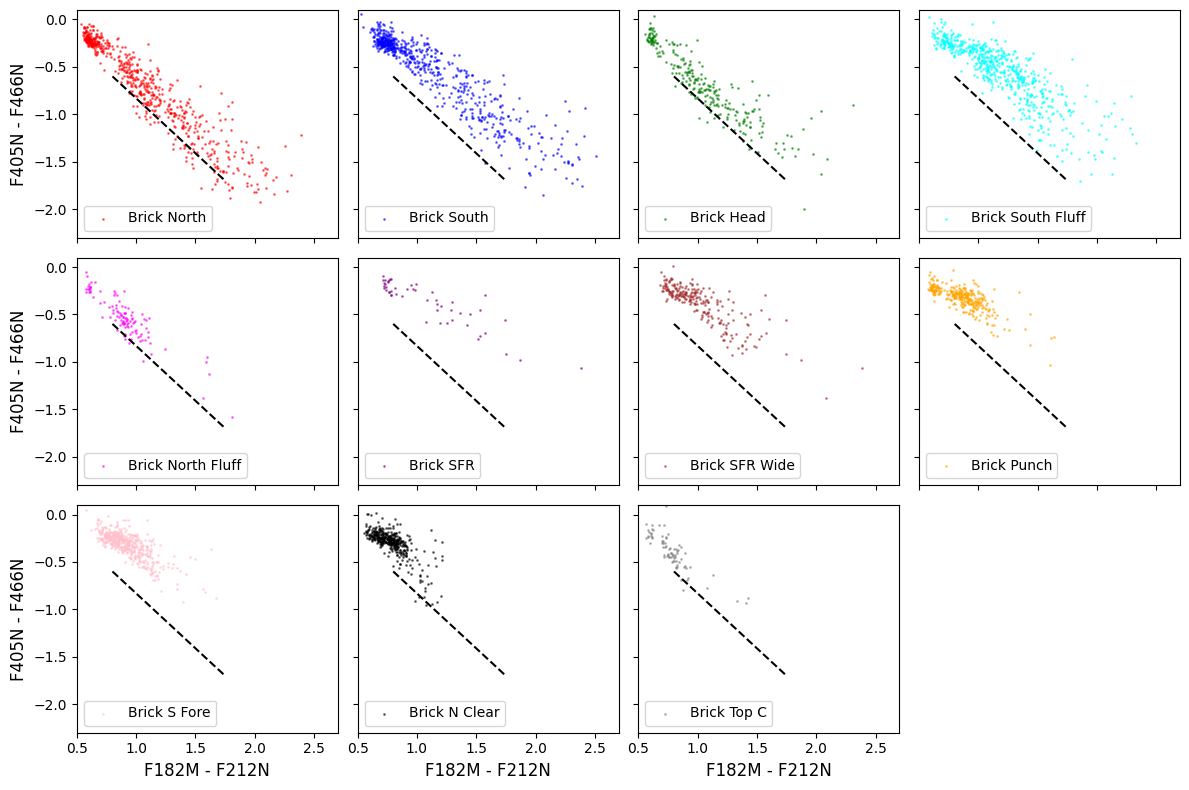

In [40]:
fig, axes = plt.subplots(3, 4, figsize=(12,8), sharex=True, sharey=True)

for i in range(len(catalogs_brick)):
    ax = axes.flatten()[i]
    cat = catalogs_brick[i]
    cat.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', ax=ax, s=1, alpha=0.5, label=labels_brick[i], color=colors_brick[i])
    if i > 7:
        ax.set_xlabel('F182M - F212N', fontsize=12)
    else: 
        ax.set_xlabel('')
    if i % 4 == 0:
        ax.set_ylabel('F405N - F466N', fontsize=12)
    else: 
        ax.set_ylabel('')
    ax.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
    ax.legend(loc='lower left')
    ax.set_xlim(0.5, 2.7)
    ax.set_ylim(-2.3, 0.1)

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/ccds_rc_brick.png', bbox_inches='tight', transparent=True, dpi=300)

# Table

In [33]:
combined_catalogs = catalogs_cloudc + catalogs_brick
combined_labels = labels_cloudc + labels_brick
combined_colors = colors_cloudc + colors_brick
combined_intersections = intersections_cloudc + intersections_brick

mean_NCO = []
std_NCO = []
unc_NCO = []
mean_CO_abund = []
std_CO_abund = []
unc_CO_abund = []

for i in range(len(combined_catalogs)):
    print(f"Processing {combined_labels[i]}...")
    cat = combined_catalogs[i]
    av_start = combined_intersections[i]
    if np.isnan(av_start):
        av_start = np.nanmin(cat.catalog['Av'])
    cat = JWSTCatalog(cat.catalog[cat.catalog['Av'] > av_start])
    cat = JWSTCatalog(cat.catalog[cat.color('f405n', 'f466n') < 0])
    nCO = cat.catalog['N(CO)']
    co_abund = cat.catalog['N(CO)'] / ((cat.catalog['Av']-av_start) * 1.1e21)

    if len(nCO) == 0:
        print(f"{combined_labels[i]}: no sources with Av > {av_start} and color < 0")
        mean_NCO.append(np.nan)
        std_NCO.append(np.nan)
        unc_NCO.append(np.nan)
        mean_CO_abund.append(np.nan)
        std_CO_abund.append(np.nan)
        unc_CO_abund.append(np.nan)
        continue
    
    mean_NCO.append(np.nanmean(nCO))
    std_NCO.append(np.nanstd(nCO))
    unc_NCO.append(std_NCO[-1] / np.sqrt(len(nCO)))
    
    mean_CO_abund.append(np.nanmean(co_abund))
    std_CO_abund.append(np.nanstd(co_abund))
    unc_CO_abund.append(std_CO_abund[-1] / np.sqrt(len(co_abund)))

    mean_CO_abund.append(np.nanmean(co_abund))
    std_CO_abund.append(np.nanstd(co_abund))
    unc_CO_abund.append(std_CO_abund[-1] / np.sqrt(len(np.array(co_abund))))

Processing Filament...
Processing Cloud C1...
Processing Cloud C2...
Processing Cloud D...
Processing Cloud B...
Processing Filament Right...
Processing Left Cloud D...
Processing Cloud C North...


Processing Cloud C South...
Processing Brick North...
Processing Brick South...
Processing Brick Head...
Processing Brick South Fluff...
Processing Brick North Fluff...
Processing Brick SFR...
Processing Brick SFR Wide...
Processing Brick Punch...
Processing Brick S Fore...
Processing Brick N Clear...
Processing Brick Top C...


ValueError: x and y must be the same size

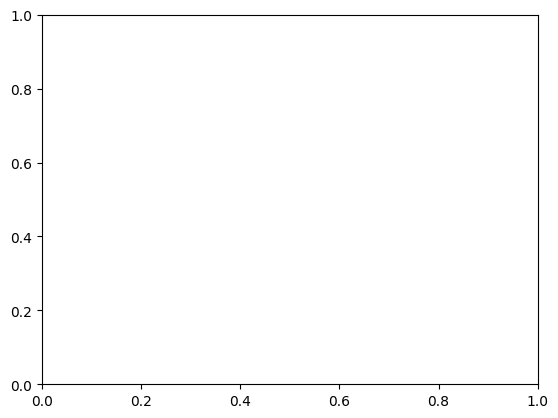

In [34]:
plt.scatter(combined_slopes, combined_intersections)

# Making Av vs N(CO Ice)

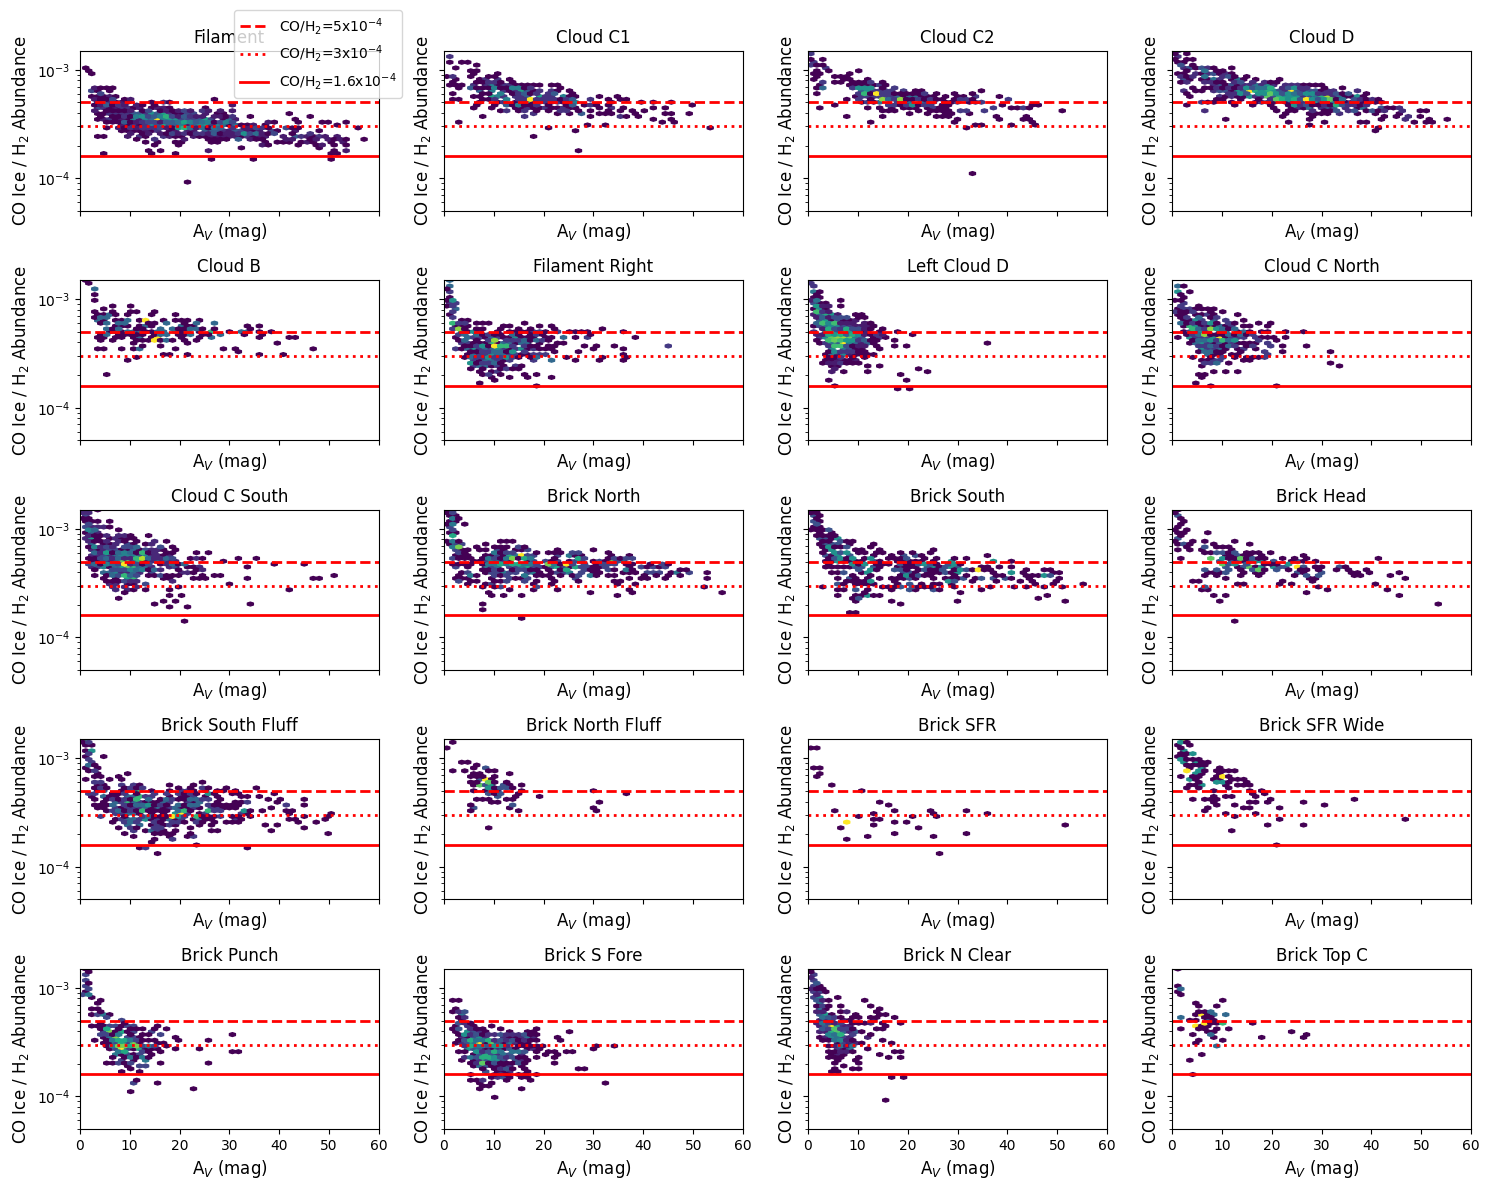

In [217]:
fig, axes = plt.subplots(5, 4, figsize=(15, 12), sharex=True, sharey=True)

for i in range(20):
    ax = axes.flatten()[i]
    cat = combined_catalogs[i]
    cat = JWSTCatalog(cat.catalog[cat.color('f405n', 'f466n') < -0.1])
    av_start = combined_intersections[i]-2
    if np.isnan(av_start):
        av_start = np.nanmean(cat.catalog['Av'])-2*np.nanstd(cat.catalog['Av'])
    cat = JWSTCatalog(cat.catalog[cat.catalog['Av'] > av_start])
    abundance_calc = cat.catalog['N(CO)']/((cat.catalog['Av']-av_start)*1.1e21)
    ax.hexbin(cat.catalog['Av']-av_start, abundance_calc, yscale='log', extent=(0, 60, np.log10(5e-5), np.log10(1.5e-3)), cmap='viridis', gridsize=50, mincnt=1)
    ax.set_title(combined_labels[i])

    ax.axhline(5e-4, linewidth=2, color='r', linestyle='--', label='CO/H$_2$=5x10$^{-4}$')
    ax.axhline(3e-4, linewidth=2, color='r', linestyle=':', label='CO/H$_2$=3x10$^{-4}$')
    ax.axhline(1.6e-4, linewidth=2, color='r', linestyle='-', label='CO/H$_2$=1.6x10$^{-4}$')

    ax.set_xlabel('A$_V$ (mag)', fontsize=12)
    ax.set_ylabel('CO Ice / H$_2$ Abundance', fontsize=12)
    ax.set_yscale('log')
    ax.set_xlim(0, 60)
    ax.set_ylim(5e-5, 1.5e-3)

    if i == 0:
        ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.3))

plt.tight_layout()

#plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_abund.png', dpi=300, bbox_inches='tight')
#plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_abund.pdf', bbox_inches='tight')

# Measuring Volume Density

In [ ]:
combined_NH2 = [(combined_highAv[i]-combined_intersections[i]) * 1.1e21 * u.cm**-2 for i in range(len(combined_catalogs))]
regionslist_cloudc = [reg_f, reg_c1, reg_c2, reg_d, reg_b, reg_fil_r, reg_left_cd, reg_c_s, reg_c_n]
#[reg_north, reg_south, reg_head, reg_sfluff, reg_nfluff, reg_sfr, reg_sfrwide, reg_punch, reg_sfore, reg_nclear, reg_topc]
regionslist_brick = [reg_brick_north, reg_brick_south, reg_brick_head, reg_brick_sfluff, reg_brick_nfluff, reg_brick_sfr, reg_brick_sfrwide, reg_brick_punch, reg_brick_sfore, reg_brick_nclear, reg_brick_topc]
combined_regionlist = regionslist_cloudc + regionslist_brick


In [ ]:
from astropy.wcs.utils import proj_plane_pixel_area

((proj_plane_pixel_area(ww) * reg_f[0].to_pixel(ww).area)*u.deg**2).to(u.arcsec**2)

<Quantity 8615.81428778 arcsec2>

In [ ]:
# convert deg^2 to cm^2
distance_f = 5*u.kpc
distance_GC = 8.1*u.kpc
combined_area_cm = []
combined_len_cm = []

for reg in combined_regionlist:
    if reg == reg_f:
        distance = distance_f
    else:
        distance = distance_GC
    area_deg2 = (proj_plane_pixel_area(ww) * reg[0].to_pixel(ww).area)*u.deg**2
    area_cm2 = (area_deg2.to(u.rad**2) * (distance.to(u.cm)**2)/u.rad**2).to(u.cm**2)
    combined_area_cm.append(area_cm2)
    combined_len_cm.append(np.sqrt(area_cm2))

In [ ]:
combined_nH = [NH2 / length for NH2, length in zip(combined_NH2, combined_len_cm)]
for i in range(len(combined_catalogs)):
    print(f"{combined_labels[i]}: nH = {combined_nH[i].value:.2e} cm^-3")

Filament: nH = 6.08e+03 cm^-3
Cloud C1: nH = 4.01e+03 cm^-3
Cloud C2: nH = 4.58e+03 cm^-3
Cloud D: nH = 3.69e+03 cm^-3
Cloud B: nH = 5.92e+03 cm^-3
Filament Right: nH = 3.05e+03 cm^-3
Left Cloud D: nH = 1.03e+03 cm^-3
Cloud C North: nH = 1.69e+03 cm^-3
Cloud C South: nH = 2.54e+03 cm^-3
Brick North: nH = 4.06e+03 cm^-3
Brick South: nH = 4.00e+03 cm^-3
Brick Head: nH = 5.00e+03 cm^-3
Brick South Fluff: nH = 4.20e+03 cm^-3
Brick North Fluff: nH = 2.90e+03 cm^-3
Brick SFR: nH = 1.17e+04 cm^-3
Brick SFR Wide: nH = 6.90e+02 cm^-3
Brick Punch: nH = 2.17e+03 cm^-3
Brick S Fore: nH = 2.56e+03 cm^-3
Brick N Clear: nH = 1.99e+03 cm^-3
Brick Top C: nH = 2.90e+03 cm^-3


# Experiments in Gaussian Mixture Modeling

In [ ]:
from sklearn.mixture import GaussianMixture

In [ ]:
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/2/sigma**2)

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

array([11598])

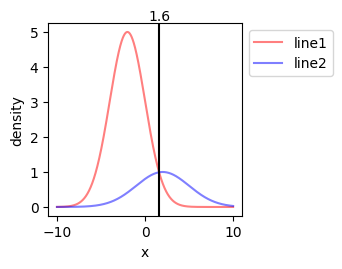

In [ ]:
# Source - https://stackoverflow.com/a/65149338
# Posted by user3521099
# Retrieved 2026-04-01, License - CC BY-SA 4.0

def get_intersection_locations(y1,y2,test=False,x=None): 
    """
    return indices of the intersection point/s.
    """
    idxs=np.argwhere(np.diff(np.sign(y1 - y2))).flatten()
    if test:
        x=range(len(y1)) if x is None else x
        plt.figure(figsize=[2.5,2.5])
        ax=plt.subplot()
        ax.plot(x,y1,color='r',label='line1',alpha=0.5)
        ax.plot(x,y2,color='b',label='line2',alpha=0.5)
        _=[ax.axvline(x[i],color='k') for i in idxs]
        _=[ax.text(x[i],ax.get_ylim()[1],f"{x[i]:1.1f}",ha='center',va='bottom') for i in idxs]
        ax.legend(bbox_to_anchor=[1,1])
        ax.set(xlabel='x',ylabel='density')
    return idxs

# Source - https://stackoverflow.com/a/65149338
# Posted by user3521099
# Retrieved 2026-04-01, License - CC BY-SA 4.0

# single intersection
x = np.arange(-10, 10, 0.001)
y1=gauss(x, -2, 2, 5)
y2=gauss(x, 2, 3, 1)
get_intersection_locations(y1=y1,y2=y2,x=x,test=True) # returns indice/s array([10173])


            params     sigma
mu1       1.014589  0.005273
sigma1    0.203826  0.004067
A1      230.654585  3.667409
mu2       1.635225  0.022423
sigma2    0.282690  0.019070
A2       72.621856  2.148459


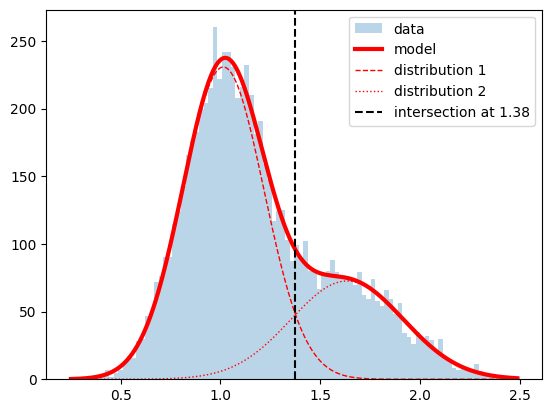

In [ ]:
# Source - https://stackoverflow.com/a/70907042
# Posted by Mr. T, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-01, License - CC BY-SA 4.0

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

#data generation
np.random.seed(123)
data=np.concatenate((np.random.normal(1, .2, 5000), np.random.normal(1.6, .3, 2500)))
y,x,_=plt.hist(data, 100, alpha=.3, label='data')
x=(x[1:]+x[:-1])/2 # for len(x)==len(y)

#x, y inputs can be lists or 1D numpy arrays

def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/2/sigma**2)

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def trimodal(x, mu1, sigma1, A1, mu2, sigma2, A2, mu3, sigma3, A3):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)

expected = (1, .2, 250, 2, .2, 125)
params, cov = curve_fit(bimodal, x, y, expected)
sigma=np.sqrt(np.diag(cov))
x_fit = np.linspace(x.min(), x.max(), 500)
#plot combined...
plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
#...and individual Gauss curves
plt.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=1, ls="--", label='distribution 1')
plt.plot(x_fit, gauss(x_fit, *params[3:]), color='red', lw=1, ls=":", label='distribution 2')
#and the original data points if no histogram has been created before
#plt.scatter(x, y, marker="X", color="black", label="original data")

print(pd.DataFrame(data={'params': params, 'sigma': sigma}, index=bimodal.__code__.co_varnames[1:]))

x = np.linspace(0, 5, 100000)
y1=gauss(x, params[0], params[1], params[2])
y2=gauss(x, params[3], params[4], params[5])
idxs = get_intersection_locations(y1=y1,y2=y2,x=x)
plt.axvline(x[idxs[0]], color='k', ls='--', label=f'intersection at {x[idxs[0]]:1.2f}')
plt.legend()
plt.show() 


In [ ]:
from scipy.optimize import curve_fit
import pandas as pd

           params     sigma
mu1     21.078101  0.310677
sigma1   1.470471  0.249363
A1      83.583870  9.006947
mu2     37.322671  0.770694
sigma2   8.984777  0.864303
A2      48.162499  3.156980


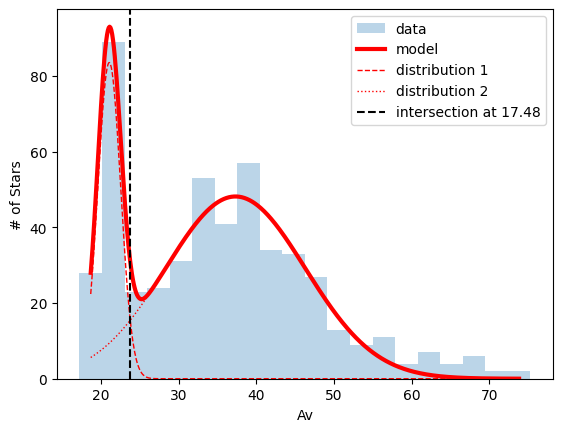

In [ ]:
data = cat_c1_rc.catalog['Av'].flatten()
y,x,_=plt.hist(data, 20, alpha=.3, label='data')
x=(x[1:]+x[:-1])/2

mu1_guess = 20
sigma1_guess = 5
A1_guess = 50

mu2_guess = 40
sigma2_guess = 10
A2_guess = 50

expected = (mu1_guess, sigma1_guess, A1_guess, mu2_guess, sigma2_guess, A2_guess)
params, cov = curve_fit(bimodal, x, y, expected)
sigma=np.sqrt(np.diag(cov))
x_fit = np.linspace(x.min(), x.max(), 500)
#plot combined...
plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
plt.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=1, ls="--", label='distribution 1')
plt.plot(x_fit, gauss(x_fit, *params[3:]), color='red', lw=1, ls=":", label='distribution 2')

plt.xlabel('Av')
plt.ylabel('# of Stars')
plt.legend()
print(pd.DataFrame(data={'params': params, 'sigma': sigma}, index=bimodal.__code__.co_varnames[1:]))

x = np.linspace(0, 70, 10000)
y1=gauss(x, params[0], params[1], params[2])
y2=gauss(x, params[3], params[4], params[5])
idxs = get_intersection_locations(y1=y1,y2=y2,x=x)
plt.axvline(x[idxs[1]], color='k', ls='--', label=f'intersection at {x[idxs[0]]:1.2f}')

plt.legend()


           params      sigma
mu1     20.824281   0.164377
sigma1   1.010708   0.316564
A1      74.700056  20.987130
mu2     38.058274   0.850929
sigma2   9.286486   0.936605
A2      25.892379   1.978552


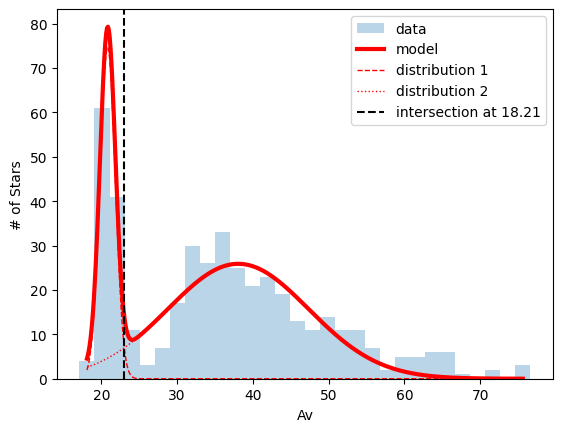

In [ ]:
data = cat_c2_rc.catalog['Av'].flatten()
y,x,_=plt.hist(data, 30, alpha=.3, label='data')
x=(x[1:]+x[:-1])/2

mu1_guess = 20
sigma1_guess = 1
A1_guess = 50

mu2_guess = 40
sigma2_guess = 10
A2_guess = 25

expected = (mu1_guess, sigma1_guess, A1_guess, mu2_guess, sigma2_guess, A2_guess)
params, cov = curve_fit(bimodal, x, y, expected)
sigma=np.sqrt(np.diag(cov))
x_fit = np.linspace(x.min(), x.max(), 500)
#plot combined...
plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
plt.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=1, ls="--", label='distribution 1')
plt.plot(x_fit, gauss(x_fit, *params[3:]), color='red', lw=1, ls=":", label='distribution 2')

plt.xlabel('Av')
plt.ylabel('# of Stars')
plt.legend()
print(pd.DataFrame(data={'params': params, 'sigma': sigma}, index=bimodal.__code__.co_varnames[1:]))

x = np.linspace(0, 70, 10000)
y1=gauss(x, params[0], params[1], params[2])
y2=gauss(x, params[3], params[4], params[5])
idxs = get_intersection_locations(y1=y1,y2=y2,x=x)
plt.axvline(x[idxs[1]], color='k', ls='--', label=f'intersection at {x[idxs[0]]:1.2f}')

plt.legend()


            params     sigma
mu1      19.646713  0.078824
sigma1    1.407125  0.063409
A1      152.624457  6.390209
mu2      43.640445  0.623894
sigma2   12.897515  0.684487
A2       56.295640  2.287660


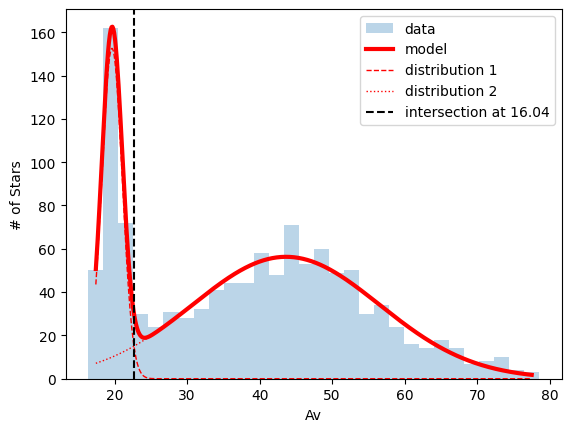

In [ ]:
data = cat_d_rc.catalog['Av'].flatten()
y,x,_=plt.hist(data, 30, alpha=.3, label='data')
x=(x[1:]+x[:-1])/2

mu1_guess = 20
sigma1_guess = 1
A1_guess = 50

mu2_guess = 40
sigma2_guess = 10
A2_guess = 25

expected = (mu1_guess, sigma1_guess, A1_guess, mu2_guess, sigma2_guess, A2_guess)
params, cov = curve_fit(bimodal, x, y, expected)
sigma=np.sqrt(np.diag(cov))
x_fit = np.linspace(x.min(), x.max(), 500)
#plot combined...
plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
plt.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=1, ls="--", label='distribution 1')
plt.plot(x_fit, gauss(x_fit, *params[3:]), color='red', lw=1, ls=":", label='distribution 2')

plt.xlabel('Av')
plt.ylabel('# of Stars')
plt.legend()
print(pd.DataFrame(data={'params': params, 'sigma': sigma}, index=bimodal.__code__.co_varnames[1:]))

x = np.linspace(0, 70, 10000)
y1=gauss(x, params[0], params[1], params[2])
y2=gauss(x, params[3], params[4], params[5])
idxs = get_intersection_locations(y1=y1,y2=y2,x=x)
plt.axvline(x[idxs[1]], color='k', ls='--', label=f'intersection at {x[idxs[0]]:1.2f}')

plt.legend()


           params        sigma
mu1     20.909130     8.922786
sigma1   0.617486    12.770831
A1      49.881398  2141.108155
mu2     31.715106     1.332532
sigma2  11.528145     1.317260
A2      20.882317     1.164438


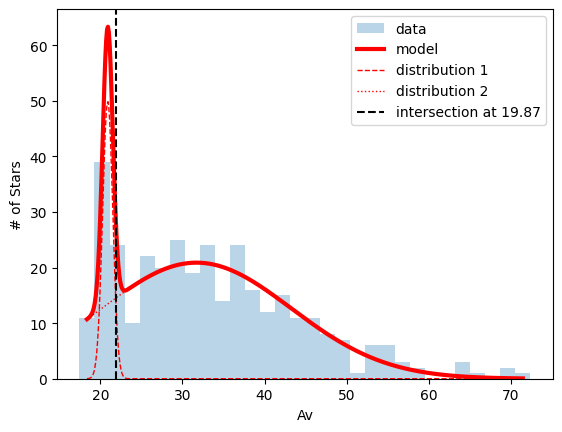

In [ ]:
data = cat_b_rc.catalog['Av'].flatten()
y,x,_=plt.hist(data, 30, alpha=.3, label='data')
x=(x[1:]+x[:-1])/2

mu1_guess = 20
sigma1_guess = 2
A1_guess = 50

mu2_guess = 40
sigma2_guess = 10
A2_guess = 25

expected = (mu1_guess, sigma1_guess, A1_guess, mu2_guess, sigma2_guess, A2_guess)
params, cov = curve_fit(bimodal, x, y, expected)
sigma=np.sqrt(np.diag(cov))
x_fit = np.linspace(x.min(), x.max(), 500)
#plot combined...
plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
plt.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=1, ls="--", label='distribution 1')
plt.plot(x_fit, gauss(x_fit, *params[3:]), color='red', lw=1, ls=":", label='distribution 2')

plt.xlabel('Av')
plt.ylabel('# of Stars')
plt.legend()
print(pd.DataFrame(data={'params': params, 'sigma': sigma}, index=bimodal.__code__.co_varnames[1:]))

x = np.linspace(0, 70, 10000)
y1=gauss(x, params[0], params[1], params[2])
y2=gauss(x, params[3], params[4], params[5])
idxs = get_intersection_locations(y1=y1,y2=y2,x=x)
plt.axvline(x[idxs[1]], color='k', ls='--', label=f'intersection at {x[idxs[0]]:1.2f}')

plt.legend()


           params     sigma
mu1     19.892966  0.246918
sigma1   0.415057  0.139493
A1      19.788601  3.932037
mu2     26.124078  0.212460
sigma2   4.401773  0.221805
A2      39.379003  1.424752


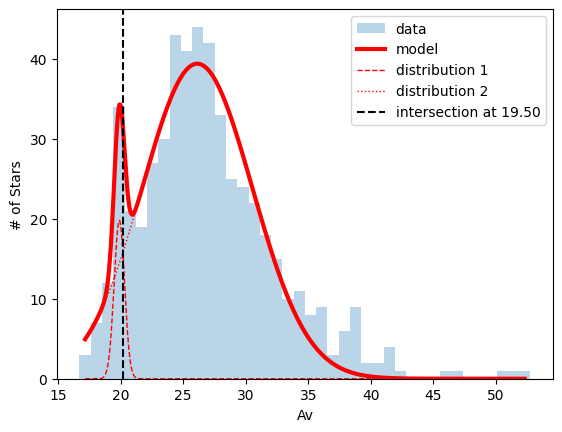

In [ ]:
data = cat_c_n_rc.catalog['Av'].flatten()
y,x,_=plt.hist(data, 40, alpha=.3, label='data')
x=(x[1:]+x[:-1])/2

mu1_guess = 20
sigma1_guess = 1
A1_guess = 35

mu2_guess = 27
sigma2_guess = 10
A2_guess = 60

expected = (mu1_guess, sigma1_guess, A1_guess, mu2_guess, sigma2_guess, A2_guess)
params, cov = curve_fit(bimodal, x, y, expected)
sigma=np.sqrt(np.diag(cov))
x_fit = np.linspace(x.min(), x.max(), 500)
#plot combined...
plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
plt.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=1, ls="--", label='distribution 1')
plt.plot(x_fit, gauss(x_fit, *params[3:]), color='red', lw=1, ls=":", label='distribution 2')

plt.xlabel('Av')
plt.ylabel('# of Stars')
plt.legend()
print(pd.DataFrame(data={'params': params, 'sigma': sigma}, index=bimodal.__code__.co_varnames[1:]))

x = np.linspace(0, 70, 10000)
y1=gauss(x, params[0], params[1], params[2])
y2=gauss(x, params[3], params[4], params[5])
idxs = get_intersection_locations(y1=y1,y2=y2,x=x)
plt.axvline(x[idxs[1]], color='k', ls='--', label=f'intersection at {x[idxs[0]]:1.2f}')

plt.legend()


           params     sigma
mu1     20.762596  0.089353
sigma1   1.330106  0.110422
A1      87.810963  5.850317
mu2     29.646746  0.290167
sigma2   5.460735  0.314106
A2      74.469823  2.551121


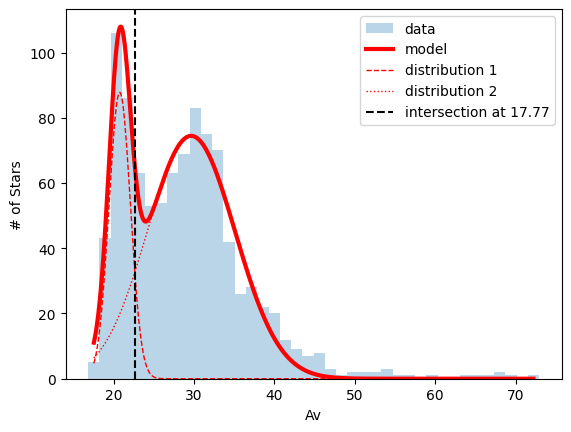

In [ ]:
data = cat_c_s_rc.catalog['Av'].flatten()
y,x,_=plt.hist(data, 40, alpha=.3, label='data')
x=(x[1:]+x[:-1])/2

mu1_guess = 20
sigma1_guess = 5
A1_guess = 100

mu2_guess = 27
sigma2_guess = 10
A2_guess = 80

expected = (mu1_guess, sigma1_guess, A1_guess, mu2_guess, sigma2_guess, A2_guess)
params, cov = curve_fit(bimodal, x, y, expected)
sigma=np.sqrt(np.diag(cov))
x_fit = np.linspace(x.min(), x.max(), 500)
#plot combined...
plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
plt.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=1, ls="--", label='distribution 1')
plt.plot(x_fit, gauss(x_fit, *params[3:]), color='red', lw=1, ls=":", label='distribution 2')

plt.xlabel('Av')
plt.ylabel('# of Stars')
plt.legend()
print(pd.DataFrame(data={'params': params, 'sigma': sigma}, index=bimodal.__code__.co_varnames[1:]))

x = np.linspace(0, 70, 10000)
y1=gauss(x, params[0], params[1], params[2])
y2=gauss(x, params[3], params[4], params[5])
idxs = get_intersection_locations(y1=y1,y2=y2,x=x)
plt.axvline(x[idxs[1]], color='k', ls='--', label=f'intersection at {x[idxs[0]]:1.2f}')

plt.legend()


           params         sigma
mu1     20.345986  1.750464e+06
sigma1   0.257884  4.779885e+05
A1      38.401277  4.549372e+06
mu2     28.009474  5.451316e-01
sigma2   6.834409  5.433528e-01
A2      55.551855  2.186425e+00


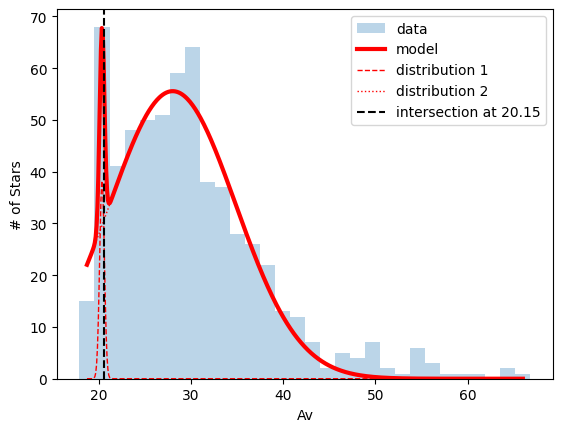

In [ ]:
data = cat_fil_r_rc.catalog['Av'].flatten()
y,x,_=plt.hist(data, 30, alpha=.3, label='data')
x=(x[1:]+x[:-1])/2

mu1_guess = 20
sigma1_guess = 2
A1_guess = 40

mu2_guess = 20
sigma2_guess = 10
A2_guess = 50

expected = (mu1_guess, sigma1_guess, A1_guess, mu2_guess, sigma2_guess, A2_guess)
params, cov = curve_fit(bimodal, x, y, expected)
sigma=np.sqrt(np.diag(cov))
x_fit = np.linspace(x.min(), x.max(), 500)
#plot combined...
plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
plt.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=1, ls="--", label='distribution 1')
plt.plot(x_fit, gauss(x_fit, *params[3:]), color='red', lw=1, ls=":", label='distribution 2')

plt.xlabel('Av')
plt.ylabel('# of Stars')
plt.legend()
print(pd.DataFrame(data={'params': params, 'sigma': sigma}, index=bimodal.__code__.co_varnames[1:]))

x = np.linspace(0, 70, 10000)
y1=gauss(x, params[0], params[1], params[2])
y2=gauss(x, params[3], params[4], params[5])
idxs = get_intersection_locations(y1=y1,y2=y2,x=x)
plt.axvline(x[idxs[1]], color='k', ls='--', label=f'intersection at {x[idxs[0]]:1.2f}')

plt.legend()
